In [18]:
import shutil

source_dir = '../evaluation_setups/fig12_eyerissv2_pe_setup/workload/mobilenet0.5-sparse/uniform'
destination_dir = '../evaluation_setups/Eyeriss_v2/workload_mobilenet'

# shutil.copytree(source_dir, destination_dir)
shutil.rmtree('../evaluation_setups/Eyeriss_v2/outputs_no_gate_old_ert')

# MICRO 2022 Artifact Evaluation
# Sparseloop: An Analytical Approach To Sparse Tensor Accelerator Modeling
### Yannan N. Wu, Po-An Tsai, Angshuman Parashar, Vivienne Sze, Joel S. Emer

## Context

In this artifact, we provide evaluation setups for the important experiments (the motivating example, validations for accelerator designs, and the case study). Please follow the instructions in each cell to run the evaluations.

For each experiment, we give a *very conservative estimate* of how long the runs will take. The input specifications and related scripts can be found in `../evaluation_setups`. **The easiest way to validate the outputs is to compare the generated figure/table to the figure/table in the paper**, but we do provide a `ref_outputs` folder for each evaluation for more detailed comparison of results if necessary.



***Please note that to allow easier and faster reproduction, for most of the experiments, we directly provide the mappings found by our offline search*** *instead of letting Sparseloop performing online seach for the best mapping.* ***Sparseloop does allow automatic exploration of various mappings*** *as demonstrated in eval1 (more information on tool usage can be found [here](https://accelergy.mit.edu/tutorial.html) and [here](https://accelergy.mit.edu/sparse_tutorial.html)).*


### If you have any questions, please feel free to reach out at timeloop-accelergy@mit.edu. Thanks!




## Eval 1: Data representation format comparison (Fig.1 in paper)

This evaluation compares the processing speed and energy efficiency of two architectures that support different representation formats: 1) bitmask with gating; 2) coordinate list with skipping, running matrix multiplication workloads with various density degrees

### Step 1: Run sweep  ( <5min)

In [ ]:
%%bash
cd ../evaluation_setups/fig1_format_comparison_setup/scripts
echo "input specs at: ../evaluation_setups/fig1_format_comparison_setup/"
chmod +x sweep.sh
time ./sweep.sh

### Step 2: Parse and generate plot
1) run first cell to parse and plot

2) run next cell to display the generated figures

3) compare the figures to Fig.1 in paper

In [ ]:
%%bash
cd ../evaluation_setups/fig1_format_comparison_setup/scripts
time python3 parse_and_plot.py

In [ ]:
from IPython.display import Video, Image, HTML, display
import matplotlib.pyplot as plt

cycles_fig = "../evaluation_setups/fig1_format_comparison_setup/outputs/fig_cycles.png"
energy_fig = "../evaluation_setups/fig1_format_comparison_setup/outputs/fig_energy_pJ.png"

display(Image(cycles_fig))
display(Image(energy_fig))

## Eval 2: EyerissV2 PE Validation ( 1. Fig.12 in paper; 2. showcase the main idea presented in Table 5)

We simulate mobilenet0.5 layers on a variation of eyeriss v2 PE with one compute unit.

We show experimental setups for both running evaluations with statistical density model (uniform density model) and actual data based density model. The modeling time is much longer with actual data based model. **This fact showcases the idea presented in Table 5: analytical modeling with statisical density model allows faster modeling.** (*Experiments for Table 5 requires manaul instrumantaion into the source code, which is not convienent for non-developers to setup, so we use this evlauation to showcase the main idea.*)

### Step 1: Run sweep with statistical density modeling (< 3min)

In [ ]:
%%bash
cd ../evaluation_setups/fig12_eyerissv2_pe_setup/scripts
echo "input specs at: ../evaluation_setups/fig12_eyerissv2_pe_setup/"
time python3 sweep.py

### Step 2: Parse and generte plot

1) run first cell to parse and generate figure

2) run next cell to diplay the generated figure

3) compare to per layer the ground truth and uniform modeling bars in Fig.12 in the paper

In [ ]:
%%bash
cd ../evaluation_setups/fig12_eyerissv2_pe_setup/scripts
python3 parse_and_plot.py

In [ ]:
from IPython.display import Video, Image, HTML, display
import matplotlib.pyplot as plt

fig = "../evaluation_setups/fig12_eyerissv2_pe_setup/outputs/uniform_only/fig.png"

display(Image(fig))

### Step 3: Run autal data evaluation on three layers ( <30 min)

Since actual data based evaluations are slow compared to statistical ones, the default evaluation only run on three layers. Please tune the `--max_layers` knob in the command below if you would like to try more layers.

**Note that this also demonstrate that our modeling speed with the statiscal density models are fast, which is the main idea presented in Table 5 in paper**

In [ ]:
%%bash
cd ../evaluation_setups/fig12_eyerissv2_pe_setup/scripts
echo "input specs at: ../evaluation_setups/fig12_eyerissv2_pe_setup/"

# update the number of max layers below (<=8) to see more bar groups in fig12, but the run will take longer
time python3 sweep.py --include_actual --max_layers 3

### Step 4: Parse and generate plot


1) run first cell to parse and generate figure

2) run next cell to diplay the generated figure

3) compare to the group of bars for **L07** in Fig.12 in the paper. 
   The main idea here is that compared to `baseline`, `acutal_data` based evlauation is able to accurately capture design behaviors with no error, whereas there is some error due statistical approximations when using the `uniform` distribution.

In [2]:
%%bash
cd ../evaluation_setups/fig12_eyerissv2_pe_setup/scripts
python3 parse_and_plot.py --include_actual

In [1]:
from IPython.display import Video, Image, HTML, display
import matplotlib.pyplot as plt

fig = "../evaluation_setups/fig12_eyerissv2_pe_setup/outputs/uniform_actual/fig.png"

display(Image(fig))

## Eval 3: Eyeriss Validation (Table 7 in paper)

We simulate the AlexNet Conv layers on the Eyeriss accelerator, and present the DRAM traffic compression ratio. 


### Step 1: Run sweep (< 5min)

In [1]:
%%bash
# EYERISS V1, NOT V2
cd ../evaluation_setups/table7_eyeriss_setup/scripts
echo "input specs at: ../evaluation_setups/table7_eyeriss_setup/"
time python3 sweep.py --search_mapping

input specs at: ../evaluation_setups/table7_eyeriss_setup/
input file: /home/workspace/2022.micro.artifact/evaluation_setups/table7_eyeriss_setup/scripts/../outputs/alexnet_conv1/aggregated_input.yaml
input file: /home/workspace/2022.micro.artifact/evaluation_setups/table7_eyeriss_setup/scripts/../outputs/alexnet_conv1/ERT.yaml
input file: /home/workspace/2022.micro.artifact/evaluation_setups/table7_eyeriss_setup/scripts/../outputs/alexnet_conv1/ART.yaml
  _______                __                
 /_  __(_)___ ___  ___  / /___  ____  ____ 
  / / / / __ `__ \/ _ \/ / __ \/ __ \/ __ \
 / / / / / / / / /  __/ / /_/ / /_/ / /_/ /
/_/ /_/_/ /_/ /_/\___/_/\____/\____/ .___/ 
                                  /_/      

Problem configuration complete.
Found Accelergy ERT (energy reference table), replacing internal energy model.
Found Accelergy ART (area reference table), replacing internal area model.
Architecture configuration complete.
Sparse optimization configuration complete.
Using thr

[  2] Utilization = 0.52 | pJ/Algorithmic-Compute =   47.636 | pJ/Compute =   47.636 | L5[WIO] Q14 M2 - L4[O] M4 N4 P56 C3 M2X Q4X - L3[] Q1 S11Y - L2[I] Q1 - L1[W] R11 - L0[O] M6  | Cycles = 4967424
[  2] Utilization = 0.92 | pJ/Algorithmic-Compute =   39.271 | pJ/Compute =   39.271 | L5[WIO] Q8 M3 - L4[O] M4 N4 P56 C3 M2X Q7X - L3[] Q1 S11Y - L2[I] Q1 - L1[W] R11 - L0[O] M4  | Cycles = 2838528
[  7] Utilization = 0.92 | pJ/Algorithmic-Compute =   20.148 | pJ/Compute =   20.148 | L5[WIO] Q4 N4 M32 C3 - L4[O] P56 Q14X - L3[] Q1 S11Y - L2[I] Q1 - L1[W] R11 - L0[O] M3  | Cycles = 2838528
[  6] Utilization = 0.92 | pJ/Algorithmic-Compute =   56.811 | pJ/Compute =   56.811 | L5[WIO] Q4 N4 M32 - L4[O] P56 C3 Q14X - L3[] Q1 S11Y - L2[I] Q1 - L1[W] R11 - L0[O] M3  | Cycles = 2838528
[  3] Utilization = 0.52 | pJ/Algorithmic-Compute =    8.100 | pJ/Compute =    8.100 | L5[WIO] Q14 M2 C3 - L4[O] M4 N4 P56 M2X Q4X - L3[] Q1 S11Y - L2[I] Q1 - L1[W] R11 - L0[O] M6  | Cycles = 4967424
[  6] Utiliza



Summary stats for best mapping found by mapper:
  Utilization = 0.92 | pJ/Algorithmic-Compute =    4.679 | pJ/Compute =    4.679 | Cycles = 2838528
input file: /home/workspace/2022.micro.artifact/evaluation_setups/table7_eyeriss_setup/scripts/../outputs/alexnet_conv2/aggregated_input.yaml
input file: /home/workspace/2022.micro.artifact/evaluation_setups/table7_eyeriss_setup/scripts/../outputs/alexnet_conv2/ERT.yaml
input file: /home/workspace/2022.micro.artifact/evaluation_setups/table7_eyeriss_setup/scripts/../outputs/alexnet_conv2/ART.yaml
  _______                __                
 /_  __(_)___ ___  ___  / /___  ____  ____ 
  / / / / __ `__ \/ _ \/ / __ \/ __ \/ __ \
 / / / / / / / / /  __/ / /_/ / /_/ / /_/ /
/_/ /_/_/ /_/ /_/\___/_/\____/\____/ .___/ 
                                  /_/      

Problem configuration complete.
Found Accelergy ERT (energy reference table), replacing internal energy model.
Found Accelergy ART (area reference table), replacing internal area model.

[  0] Utilization = 0.06 | pJ/Algorithmic-Compute =   49.776 | pJ/Compute =   82.959 | L5[WIO] Q7 M32 C12 - L4[IO] M8 N4 P28 C4 Q4X - L3[] Q1 S5Y - L2[I] Q1 - L1[W] R5 - L0[O] Q1  | Cycles = 60763137
[  3] Utilization = 0.08 | pJ/Algorithmic-Compute =   30.025 | pJ/Compute =   50.041 | L5[WIO] Q7 M4 C8 - L4[IO] M32 N2 P28 C6 Q4X - L3[] Q1 S5Y - L2[I] Q1 - L1[W] R5 N2 - L0[O] M2  | Cycles = 42097665
[  8] Utilization = 0.06 | pJ/Algorithmic-Compute =   49.661 | pJ/Compute =   82.769 | L5[WIO] Q7 M32 C6 - L4[IO] M8 N4 P28 C4 Q4X - L3[] Q1 S5Y - L2[I] Q1 - L1[W] R5 C2 - L0[O] Q1  | Cycles = 60462080
[  1] Utilization = 0.03 | pJ/Algorithmic-Compute =    9.718 | pJ/Compute =   16.196 | L5[WIO] Q28 N4 M8 C48 - L4[IO] M4 P28 - L3[] Q1 S5Y - L2[I] Q1 - L1[W] R5 - L0[O] M8  | Cycles = 115605504
[  4] Utilization = 0.03 | pJ/Algorithmic-Compute =   96.031 | pJ/Compute =  160.051 | L5[WIO] Q28 N2 M128 C2 - L4[IO] P28 C24 - L3[] Q1 S5Y - L2[I] N2 - L1[W] R5 - L0[O] M2  | Cycles = 115605504
[  4] 



Summary stats for best mapping found by mapper:
  Utilization = 0.83 | pJ/Algorithmic-Compute =    3.271 | pJ/Compute =    5.451 | Cycles = 4128768
input file: /home/workspace/2022.micro.artifact/evaluation_setups/table7_eyeriss_setup/scripts/../outputs/alexnet_conv3/aggregated_input.yaml
input file: /home/workspace/2022.micro.artifact/evaluation_setups/table7_eyeriss_setup/scripts/../outputs/alexnet_conv3/ERT.yaml
input file: /home/workspace/2022.micro.artifact/evaluation_setups/table7_eyeriss_setup/scripts/../outputs/alexnet_conv3/ART.yaml
  _______                __                
 /_  __(_)___ ___  ___  / /___  ____  ____ 
  / / / / __ `__ \/ _ \/ / __ \/ __ \/ __ \
 / / / / / / / / /  __/ / /_/ / /_/ / /_/ /
/_/ /_/_/ /_/ /_/\___/_/\____/\____/ .___/ 
                                  /_/      

Problem configuration complete.
Found Accelergy ERT (energy reference table), replacing internal energy model.
Found Accelergy ART (area reference table), replacing internal area model.

...

[  3] Utilization = 0.02 | pJ/Algorithmic-Compute =   52.111 | pJ/Compute =  226.568 | L5[WIO] Q13 M128 C4 - L4[IO] P13 C48 M2X - L3[] Q1 S3Y - L2[I] Q1 - L1[W] R3 - L0[O] N4  | Cycles = 24920064
[  3] Utilization = 0.02 | pJ/Algorithmic-Compute =   25.824 | pJ/Compute =  112.279 | L5[WIO] Q13 M128 C4 - L4[WIO] P13 C48 M2X - L3[] Q1 S3Y - L2[I] Q1 - L1[W] R3 - L0[O] N4  | Cycles = 24920064
[  2] Utilization = 0.02 | pJ/Algorithmic-Compute =   73.897 | pJ/Compute =  321.291 | L5[WIO] Q13 M16 C8 - L4[IO] M8 N2 P13 C24 - L3[] Q1 M2Y S3Y - L2[I] Q1 - L1[W] R3 - L0[O] N2  | Cycles = 24920064
[  2] Utilization = 0.02 | pJ/Algorithmic-Compute =   18.684 | pJ/Compute =   81.235 | L5[WIO] Q13 M16 C8 - L4[WIO] M8 N2 P13 C24 - L3[] Q1 M2Y S3Y - L2[I] Q1 - L1[W] R3 - L0[O] N2  | Cycles = 24920064
[  3] Utilization = 0.06 | pJ/Algorithmic-Compute =   41.967 | pJ/Compute =  182.463 | L5[WIO] Q13 M4 C4 - L4[IO] M2 P13 C48 M4X - L3[] Q1 M4Y S3Y - L2[I] Q1 - L1[W] R3 N2 - L0[O] N2 M2  | Cycles = 680326

Running job:  alexnet_conv1
Found and overwrite existing results:  /home/workspace/2022.micro.artifact/evaluation_setups/table7_eyeriss_setup/scripts/../outputs/alexnet_conv1/output
	Running test:  alexnet_conv1
alexnet_conv1  reaches timeout limit
Running job:  alexnet_conv2
Found and overwrite existing results:  /home/workspace/2022.micro.artifact/evaluation_setups/table7_eyeriss_setup/scripts/../outputs/alexnet_conv2/output
	Running test:  alexnet_conv2
alexnet_conv2  reaches timeout limit
Running job:  alexnet_conv3
Found and overwrite existing results:  /home/workspace/2022.micro.artifact/evaluation_setups/table7_eyeriss_setup/scripts/../outputs/alexnet_conv3/output
	Running test:  alexnet_conv3
alexnet_conv3  reaches timeout limit
Running job:  alexnet_conv4
Found and overwrite existing results:  /home/workspace/2022.micro.artifact/evaluation_setups/table7_eyeriss_setup/scripts/../outputs/alexnet_conv4/output
	Running test:  alexnet_conv4
alexnet_conv4  reaches timeout limit
Runn

[  0] STATEMENT: global termination flag activated, terminating search.
[ 10] STATEMENT: global termination flag activated, terminating search.
[  3] STATEMENT: global termination flag activated, terminating search.
[  7] STATEMENT: global termination flag activated, terminating search.
[ 14] STATEMENT: global termination flag activated, terminating search.
[ 15] STATEMENT: global termination flag activated, terminating search.
[ 12] STATEMENT: global termination flag activated, terminating search.
[  2] STATEMENT: global termination flag activated, terminating search.

real	18m52.122s
user	163m10.984s
sys	2m4.884s
[  9] STATEMENT: global termination flag activated, terminating search.
[  8] STATEMENT: global termination flag activated, terminating search.
[  5] STATEMENT: global termination flag activated, terminating search.
[  4] STATEMENT: global termination flag activated, terminating search.
[ 11] STATEMENT: global termination flag activated, terminating search.
[ 13] STATEMENT: 



Summary stats for best mapping found by mapper:
  Utilization = 0.43 | pJ/Algorithmic-Compute =    2.279 | pJ/Compute =    9.909 | Cycles = 958464



Error while terminating subprocess (pid=1345): 


In [4]:
%%bash
# NO GATING
cd ../evaluation_setups/Eyeriss_v2/scripts
echo "input specs at: ../evaluation_setups/Eyeriss_v2/"
time python3 sweep.py --search_mapping

input specs at: ../evaluation_setups/Eyeriss_v2/
  _______                __                
 /_  __(_)___ ___  ___  / /___  ____  ____ 
  / / / / __ `__ \/ _ \/ / __ \/ __ \/ __ \
 / / / / / / / / /  __/ / /_/ / /_/ / /_/ /
/_/ /_/_/ /_/ /_/\___/_/\____/\____/ .___/ 
                                  /_/      

Problem configuration complete.
Found Accelergy ERT (energy reference table), replacing internal energy model.
Found Accelergy ART (area reference table), replacing internal area model.
Architecture configuration complete.
Sparse optimization configuration complete.
Using threads = 16
Mapper configuration complete.
Initializing Index Factorization subspace.
  Factorization options along problem dimension C = 8
  Factorization options along problem dimension M = 6336
  Factorization options along problem dimension R = 6
  Factorization options along problem dimension S = 6
  Factorization options along problem dimension N = 55
  Factorization options along problem dimension P = 

[  5] STATEMENT: 3000 invalid mappings (2999 fanout, 1 capacity) found since the last valid mapping, terminating search.
[  4] STATEMENT: 3000 invalid mappings (2995 fanout, 5 capacity) found since the last valid mapping, terminating search.
[  3] STATEMENT: 3000 invalid mappings (2994 fanout, 6 capacity) found since the last valid mapping, terminating search.
[  2] STATEMENT: 3000 invalid mappings (2998 fanout, 2 capacity) found since the last valid mapping, terminating search.
[ 13] STATEMENT: 3000 invalid mappings (3000 fanout, 0 capacity) found since the last valid mapping, terminating search.
[ 15] STATEMENT: 3000 invalid mappings (2994 fanout, 6 capacity) found since the last valid mapping, terminating search.
[ 10] STATEMENT: 3000 invalid mappings (2998 fanout, 2 capacity) found since the last valid mapping, terminating search.
[ 11] STATEMENT: 3000 invalid mappings (2995 fanout, 5 capacity) found since the last valid mapping, terminating search.
[  7] STATEMENT: 3000 invalid ma



Summary stats for best mapping found by mapper:
  Utilization = 0.51 | pJ/Algorithmic-Compute =    2.431 | pJ/Compute =    2.431
  _______                __                
 /_  __(_)___ ___  ___  / /___  ____  ____ 
  / / / / __ `__ \/ _ \/ / __ \/ __ \/ __ \
 / / / / / / / / /  __/ / /_/ / /_/ / /_/ /
/_/ /_/_/ /_/ /_/\___/_/\____/\____/ .___/ 
                                  /_/      

Problem configuration complete.
Found Accelergy ERT (energy reference table), replacing internal energy model.
Found Accelergy ART (area reference table), replacing internal area model.
Architecture configuration complete.
Sparse optimization configuration complete.
Using threads = 16
Mapper configuration complete.
Initializing Index Factorization subspace.
  Factorization options along problem dimension C = 2640
  Factorization options along problem dimension M = 6435
  Factorization options along problem dimension R = 6
  Factorization options along problem dimension S = 6
  Factorization option

[  3] Utilization = 0.50 | pJ/Algorithmic-Compute =    2.805 | pJ/Compute =    2.805 | L7[WIO] N2 - L6[] Q14 P2X C8X - L5[I] P2 N2 Q2 M8 S5 R5 - L4[O] P7 M4 C6X - L3[I] Q1 - L2[W] Q1 - L1[O] M4 - L0[] M2 
[  3] Utilization = 0.50 | pJ/Algorithmic-Compute =    2.752 | pJ/Compute =    2.752 | L7[WIO] N2 - L6[] Q14 P2X C8X - L5[I] P2 N2 Q2 M8 S5 R5 - L4[O] P7 M4 C6X - L3[I] Q1 - L2[W] Q1 - L1[O] M4 - L0[I] M2 
[  0] Utilization = 0.17 | pJ/Algorithmic-Compute =    2.969 | pJ/Compute =    2.969 | L7[WIO] N2 - L6[] Q14 P2X C8X - L5[I] M8 R5 Q2 N2 P2 S5 - L4[O] P7 M4 C2X - L3[I] Q1 - L2[W] C3 - L1[O] M4 - L0[] M2 
[  0] Utilization = 0.17 | pJ/Algorithmic-Compute =    2.937 | pJ/Compute =    2.937 | L7[WIO] N2 - L6[] Q14 P2X C8X - L5[I] M8 R5 Q2 N2 P2 S5 - L4[O] P7 M4 C2X - L3[I] Q1 - L2[W] C3 - L1[O] M4 - L0[I] M2 
[ 10] Utilization = 0.08 | pJ/Algorithmic-Compute =    5.622 | pJ/Compute =    5.622 | L7[WIO] N2 - L6[] Q14 P2X C8X - L5[I] N2 Q2 R5 M8 S5 P2 - L4[O] P7 C6 M4 - L3[I] Q1 - L2[W]

[  0] Utilization = 0.17 | pJ/Algorithmic-Compute =    2.932 | pJ/Compute =    2.932 | L7[WIO] N2 - L6[] Q14 P2X C8X - L5[I] P2 S5 M8 Q2 N2 R5 - L4[O] P7 M4 C2X - L3[I] Q1 - L2[W] C3 - L1[O] M4 - L0[I] M2 
[  8] Utilization = 0.08 | pJ/Algorithmic-Compute =    3.042 | pJ/Compute =    3.042 | L7[WIO] N2 - L6[] Q14 P2X C8X - L5[I] R5 Q2 N2 M8 P2 S5 - L4[O] P7 M4 C3 - L3[I] Q1 - L2[W] C2 - L1[O] M4 - L0[] M2 
[  6] Utilization = 0.25 | pJ/Algorithmic-Compute =    3.146 | pJ/Compute =    3.146 | L7[WIO] N2 - L6[] Q14 P2X C8X - L5[I] R5 Q2 N2 M8 P2 S5 - L4[O] P7 M4 C2 C3X - L3[I] Q1 - L2[W] Q1 - L1[O] M4 - L0[] M2 
[  8] Utilization = 0.08 | pJ/Algorithmic-Compute =    3.009 | pJ/Compute =    3.009 | L7[WIO] N2 - L6[] Q14 P2X C8X - L5[I] R5 Q2 N2 M8 P2 S5 - L4[O] P7 M4 C3 - L3[I] Q1 - L2[W] C2 - L1[O] M4 - L0[I] M2 
[  6] Utilization = 0.25 | pJ/Algorithmic-Compute =    3.114 | pJ/Compute =    3.114 | L7[WIO] N2 - L6[] Q14 P2X C8X - L5[I] R5 Q2 N2 M8 P2 S5 - L4[O] P7 M4 C2 C3X - L3[I] Q1 - 

...

[ 11] Utilization = 0.17 | pJ/Algorithmic-Compute =    3.384 | pJ/Compute =    3.384 | L7[WIO] S3 P13 M2 R3 - L6[] M4 C4 N2X M2X C4X - L5[I] M4 - L4[O] C4 Q13 N2X - L3[I] Q1 - L2[W] Q1 - L1[O] M4 - L0[] C3 
[ 11] Utilization = 0.17 | pJ/Algorithmic-Compute =    3.118 | pJ/Compute =    3.118 | L7[WIO] S3 P13 M2 R3 - L6[] M4 C4 N2X M2X C4X - L5[I] M4 - L4[O] C4 Q13 N2X - L3[I] Q1 - L2[W] Q1 - L1[O] M4 - L0[O] C3 
[  0] Utilization = 0.33 | pJ/Algorithmic-Compute =    3.132 | pJ/Compute =    3.132 | L7[WIO] S3 P13 M2 R3 - L6[] M4 C4 N2X M2X C4X - L5[I] M4 - L4[O] Q13 C2 N2X C2X - L3[I] Q1 - L2[W] Q1 - L1[O] M4 - L0[] C3 
[  7] Utilization = 0.17 | pJ/Algorithmic-Compute =    3.131 | pJ/Compute =    3.131 | L7[WIO] P13 R3 M2 S3 - L6[] M4 C4 N2X M2X C4X - L5[I] M4 - L4[O] C3 Q13 N2X - L3[I] Q1 - L2[W] C4 - L1[O] M4 - L0[] Q1 
[ 10] Utilization = 0.67 | pJ/Algorithmic-Compute =    3.074 | pJ/Compute =    3.074 | L7[WIO] S3 P13 R3 M2 - L6[] M4 C4 N2X M2X C4X - L5[I] M4 - L4[O] C3 Q13 N2X C4X 

[ 13] Utilization = 0.50 | pJ/Algorithmic-Compute =    2.819 | pJ/Compute =    2.819 | L7[WIO] S3 R3 P13 M2 - L6[] M4 C4 N2X M2X C4X - L5[I] M4 - L4[O] Q13 C4 N2X C3X - L3[I] Q1 - L2[W] Q1 - L1[O] M4 - L0[I] Q1 
[ 12] Utilization = 0.17 | pJ/Algorithmic-Compute =    3.106 | pJ/Compute =    3.106 | L7[WIO] S3 R3 P13 M2 - L6[] M4 C4 N2X M2X C4X - L5[I] M4 - L4[O] Q13 C4 N2X - L3[I] Q1 - L2[W] C3 - L1[O] M4 - L0[] Q1 
[ 12] Utilization = 0.17 | pJ/Algorithmic-Compute =    3.098 | pJ/Compute =    3.098 | L7[WIO] S3 R3 P13 M2 - L6[] M4 C4 N2X M2X C4X - L5[I] M4 - L4[O] Q13 C4 N2X - L3[I] Q1 - L2[W] C3 - L1[O] M4 - L0[I] Q1 
[ 14] Utilization = 0.17 | pJ/Algorithmic-Compute =    3.106 | pJ/Compute =    3.106 | L7[WIO] S3 R3 P13 M2 - L6[] M4 C4 N2X M2X C4X - L5[I] M4 - L4[O] Q13 C6 N2X - L3[I] Q1 - L2[W] Q1 - L1[O] M4 - L0[] C2 
[ 14] Utilization = 0.17 | pJ/Algorithmic-Compute =    2.961 | pJ/Compute =    2.961 | L7[WIO] S3 R3 P13 M2 - L6[] M4 C4 N2X M2X C4X - L5[I] M4 - L4[O] Q13 C6 N2X - L

[  6] Utilization = 0.50 | pJ/Algorithmic-Compute =    3.223 | pJ/Compute =    3.223 | L7[WIO] C12 M2 S3 - L6[] Q13 N2 M2 R3X C4X - L5[I] M16 - L4[O] P13 N2X M2X C2X - L3[I] Q1 - L2[W] Q1 - L1[O] M2 - L0[] C2 
[  6] Utilization = 0.50 | pJ/Algorithmic-Compute =    3.076 | pJ/Compute =    3.076 | L7[WIO] C12 M2 S3 - L6[] Q13 N2 M2 R3X C4X - L5[I] M16 - L4[O] P13 N2X M2X C2X - L3[I] Q1 - L2[W] Q1 - L1[O] M2 - L0[O] C2 
[  4] STATEMENT: 3000 invalid mappings (2993 fanout, 7 capacity) found since the last valid mapping, terminating search.
[ 15] Utilization = 0.50 | pJ/Algorithmic-Compute =    4.061 | pJ/Compute =    4.061 | L7[WIO] S3 M2 C12 - L6[] Q13 N2 M2 R3X C4X - L5[I] M16 C2 - L4[O] P13 N2X M2X C2X - L3[I] Q1 - L2[W] Q1 - L1[O] M2 - L0[] Q1 
[  5] STATEMENT: 3000 invalid mappings (2992 fanout, 8 capacity) found since the last valid mapping, terminating search.
[  6] STATEMENT: 3000 invalid mappings (2992 fanout, 8 capacity) found since the last valid mapping, terminating search.
[ 1



Summary stats for best mapping found by mapper:
  Utilization = 1.00 | pJ/Algorithmic-Compute =    2.492 | pJ/Compute =    2.492
/home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs
/home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../workload_alexnet/alexnet_conv1.yaml
0.999
Running job:  alexnet_conv1
Found and overwrite existing results:  /home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs/alexnet_conv1/output
	Running test:  alexnet_conv1
/home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../workload_alexnet/alexnet_conv2.yaml
0.6
Running job:  alexnet_conv2
Found and overwrite existing results:  /home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs/alexnet_conv2/output
	Running test:  alexnet_conv2
/home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../workload_alexnet/alexnet_conv3.yaml
0.275
Running job:  alexnet_conv3
F


real	5m36.530s
user	49m3.003s
sys	0m16.069s


In [1]:
%%bash
# SINGLE GATING
cd ../evaluation_setups/Eyeriss_v2/scripts
echo "input specs at: ../evaluation_setups/Eyeriss_v2/"
time python3 sweep.py --search_mapping --output_dir "outputs_single_gate"

input specs at: ../evaluation_setups/Eyeriss_v2/
  _______                __                
 /_  __(_)___ ___  ___  / /___  ____  ____ 
  / / / / __ `__ \/ _ \/ / __ \/ __ \/ __ \
 / / / / / / / / /  __/ / /_/ / /_/ / /_/ /
/_/ /_/_/ /_/ /_/\___/_/\____/\____/ .___/ 
                                  /_/      

Problem configuration complete.
Found Accelergy ERT (energy reference table), replacing internal energy model.
Found Accelergy ART (area reference table), replacing internal area model.
Architecture configuration complete.
Sparse optimization configuration complete.
Using threads = 16
Mapper configuration complete.
Initializing Index Factorization subspace.
  Factorization options along problem dimension C = 8
  Factorization options along problem dimension M = 6336
  Factorization options along problem dimension R = 6
  Factorization options along problem dimension S = 6
  Factorization options along problem dimension N = 55
  Factorization options along problem dimension P = 

[ 10] STATEMENT: 3000 invalid mappings (2998 fanout, 2 capacity) found since the last valid mapping, terminating search.
[  5] STATEMENT: 3000 invalid mappings (2999 fanout, 1 capacity) found since the last valid mapping, terminating search.
[  2] STATEMENT: 3000 invalid mappings (2998 fanout, 2 capacity) found since the last valid mapping, terminating search.
[  3] STATEMENT: 3000 invalid mappings (2994 fanout, 6 capacity) found since the last valid mapping, terminating search.
[  4] STATEMENT: 3000 invalid mappings (2995 fanout, 5 capacity) found since the last valid mapping, terminating search.
[  7] STATEMENT: 3000 invalid mappings (2994 fanout, 6 capacity) found since the last valid mapping, terminating search.
[ 13] STATEMENT: 3000 invalid mappings (3000 fanout, 0 capacity) found since the last valid mapping, terminating search.
[ 12] STATEMENT: 3000 invalid mappings (2995 fanout, 5 capacity) found since the last valid mapping, terminating search.
[ 11] STATEMENT: 3000 invalid ma



Summary stats for best mapping found by mapper:
  Utilization = 0.51 | pJ/Algorithmic-Compute =    2.431 | pJ/Compute =    2.431
  _______                __                
 /_  __(_)___ ___  ___  / /___  ____  ____ 
  / / / / __ `__ \/ _ \/ / __ \/ __ \/ __ \
 / / / / / / / / /  __/ / /_/ / /_/ / /_/ /
/_/ /_/_/ /_/ /_/\___/_/\____/\____/ .___/ 
                                  /_/      

Problem configuration complete.
Found Accelergy ERT (energy reference table), replacing internal energy model.
Found Accelergy ART (area reference table), replacing internal area model.
Architecture configuration complete.
Sparse optimization configuration complete.
Using threads = 16
Mapper configuration complete.
Initializing Index Factorization subspace.
  Factorization options along problem dimension C = 2640
  Factorization options along problem dimension M = 6435
  Factorization options along problem dimension R = 6
  Factorization options along problem dimension S = 6
  Factorization option

[  3] Utilization = 0.50 | pJ/Algorithmic-Compute =    2.453 | pJ/Compute =    4.089 | L7[WIO] N2 - L6[] Q14 P2X C8X - L5[I] P2 N2 Q2 M8 S5 R5 - L4[O] P7 M4 C6X - L3[I] Q1 - L2[W] Q1 - L1[O] M4 - L0[] M2 
[  3] Utilization = 0.50 | pJ/Algorithmic-Compute =    2.401 | pJ/Compute =    4.001 | L7[WIO] N2 - L6[] Q14 P2X C8X - L5[I] P2 N2 Q2 M8 S5 R5 - L4[O] P7 M4 C6X - L3[I] Q1 - L2[W] Q1 - L1[O] M4 - L0[I] M2 
[  0] Utilization = 0.17 | pJ/Algorithmic-Compute =    2.554 | pJ/Compute =    4.257 | L7[WIO] N2 - L6[] Q14 P2X C8X - L5[I] M8 R5 Q2 N2 P2 S5 - L4[O] P7 M4 C2X - L3[I] Q1 - L2[W] C3 - L1[O] M4 - L0[] M2 
[  0] Utilization = 0.17 | pJ/Algorithmic-Compute =    2.522 | pJ/Compute =    4.203 | L7[WIO] N2 - L6[] Q14 P2X C8X - L5[I] M8 R5 Q2 N2 P2 S5 - L4[O] P7 M4 C2X - L3[I] Q1 - L2[W] C3 - L1[O] M4 - L0[I] M2 
[  1] Utilization = 0.25 | pJ/Algorithmic-Compute =    2.787 | pJ/Compute =    4.645 | L7[WIO] N2 - L6[] Q14 P2X C8X - L5[I] M8 Q2 R5 P2 S5 N2 - L4[O] P7 M4 C3X - L3[I] Q1 - L2[W

[ 12] Utilization = 0.08 | pJ/Algorithmic-Compute =    3.187 | pJ/Compute =    5.312 | L7[WIO] N2 - L6[] Q14 P2X C8X - L5[I] P2 N2 S5 R5 Q2 M8 C2 - L4[O] P7 M4 - L3[I] Q1 - L2[W] C3 - L1[O] M4 - L0[] M2 
[  3] Utilization = 0.50 | pJ/Algorithmic-Compute =    2.322 | pJ/Compute =    3.870 | L7[WIO] N2 - L6[] Q14 P2X C8X - L5[I] M8 Q2 P2 R5 N2 S5 - L4[O] M4 P7 C6X - L3[I] Q1 - L2[W] Q1 - L1[O] M4 - L0[] M2 
[ 12] Utilization = 0.08 | pJ/Algorithmic-Compute =    3.155 | pJ/Compute =    5.258 | L7[WIO] N2 - L6[] Q14 P2X C8X - L5[I] P2 N2 S5 R5 Q2 M8 C2 - L4[O] P7 M4 - L3[I] Q1 - L2[W] C3 - L1[O] M4 - L0[I] M2 
[  3] Utilization = 0.50 | pJ/Algorithmic-Compute =    2.289 | pJ/Compute =    3.816 | L7[WIO] N2 - L6[] Q14 P2X C8X - L5[I] M8 Q2 P2 R5 N2 S5 - L4[O] M4 P7 C6X - L3[I] Q1 - L2[W] Q1 - L1[O] M4 - L0[I] M2 
[  0] Utilization = 0.17 | pJ/Algorithmic-Compute =    2.517 | pJ/Compute =    4.195 | L7[WIO] N2 - L6[] Q14 P2X C8X - L5[I] P2 S5 M8 Q2 N2 R5 - L4[O] P7 M4 C2X - L3[I] Q1 - L2[W] 

...

[ 14] Utilization = 0.17 | pJ/Algorithmic-Compute =    3.090 | pJ/Compute =   13.433 | L7[WIO] S3 M2 P13 R3 - L6[] M4 C4 N2X M2X C4X - L5[I] M4 - L4[O] C6 Q13 N2X - L3[I] Q1 - L2[W] Q1 - L1[O] M4 - L0[] C2 
[ 14] Utilization = 0.17 | pJ/Algorithmic-Compute =    2.944 | pJ/Compute =   12.802 | L7[WIO] S3 M2 P13 R3 - L6[] M4 C4 N2X M2X C4X - L5[I] M4 - L4[O] C6 Q13 N2X - L3[I] Q1 - L2[W] Q1 - L1[O] M4 - L0[O] C2 
[  3] Utilization = 0.50 | pJ/Algorithmic-Compute =    2.137 | pJ/Compute =    9.292 | L7[WIO] S3 P13 R3 M2 - L6[] M4 C4 N2X M2X C4X - L5[I] M4 - L4[O] C2 Q13 N2X C3X - L3[I] Q1 - L2[W] C2 - L1[O] M4 - L0[] Q1 
[  6] Utilization = 0.17 | pJ/Algorithmic-Compute =    2.333 | pJ/Compute =   10.141 | L7[WIO] P13 R3 M2 S3 - L6[] M4 C4 N2X M2X C4X - L5[I] M4 - L4[O] C3 Q13 N2X - L3[I] Q1 - L2[W] C2 - L1[O] M4 - L0[] C2 
[  1] Utilization = 0.33 | pJ/Algorithmic-Compute =    2.134 | pJ/Compute =    9.276 | L7[WIO] S3 P13 M2 R3 - L6[] M4 C4 N2X M2X C4X - L5[I] M4 - L4[O] C2 Q13 N2X C2X 

[ 12] Utilization = 0.17 | pJ/Algorithmic-Compute =    2.299 | pJ/Compute =    9.998 | L7[WIO] S3 R3 P13 M2 - L6[] M4 C4 N2X M2X C4X - L5[I] M4 - L4[O] Q13 C4 N2X - L3[I] Q1 - L2[W] C3 - L1[O] M4 - L0[I] Q1 
[ 14] Utilization = 0.17 | pJ/Algorithmic-Compute =    2.307 | pJ/Compute =   10.030 | L7[WIO] S3 R3 P13 M2 - L6[] M4 C4 N2X M2X C4X - L5[I] M4 - L4[O] Q13 C6 N2X - L3[I] Q1 - L2[W] Q1 - L1[O] M4 - L0[] C2 
[ 14] Utilization = 0.17 | pJ/Algorithmic-Compute =    2.162 | pJ/Compute =    9.399 | L7[WIO] S3 R3 P13 M2 - L6[] M4 C4 N2X M2X C4X - L5[I] M4 - L4[O] Q13 C6 N2X - L3[I] Q1 - L2[W] Q1 - L1[O] M4 - L0[O] C2 
[ 13] Utilization = 0.50 | pJ/Algorithmic-Compute =    2.150 | pJ/Compute =    9.348 | L7[WIO] S3 R3 P13 M2 - L6[] M4 C4 N2X M2X C4X - L5[I] M4 - L4[O] Q13 C4 N2X C3X - L3[I] Q1 - L2[W] Q1 - L1[O] M4 - L0[] Q1 
[ 13] Utilization = 0.50 | pJ/Algorithmic-Compute =    2.143 | pJ/Compute =    9.315 | L7[WIO] S3 R3 P13 M2 - L6[] M4 C4 N2X M2X C4X - L5[I] M4 - L4[O] Q13 C4 N2X C3X

[  6] Utilization = 0.50 | pJ/Algorithmic-Compute =    2.400 | pJ/Compute =   10.435 | L7[WIO] C12 M2 S3 - L6[] Q13 N2 M2 R3X C4X - L5[I] M16 - L4[O] P13 N2X M2X C2X - L3[I] Q1 - L2[W] Q1 - L1[O] M2 - L0[O] C2 
[  7] STATEMENT: 3000 invalid mappings (2992 fanout, 8 capacity) found since the last valid mapping, terminating search.
[  5] STATEMENT: 3000 invalid mappings (2992 fanout, 8 capacity) found since the last valid mapping, terminating search.
[ 15] Utilization = 0.50 | pJ/Algorithmic-Compute =    3.384 | pJ/Compute =   14.715 | L7[WIO] S3 M2 C12 - L6[] Q13 N2 M2 R3X C4X - L5[I] M16 C2 - L4[O] P13 N2X M2X C2X - L3[I] Q1 - L2[W] Q1 - L1[O] M2 - L0[] Q1 
[ 14] STATEMENT: 3000 invalid mappings (2993 fanout, 7 capacity) found since the last valid mapping, terminating search.
[  6] STATEMENT: 3000 invalid mappings (2992 fanout, 8 capacity) found since the last valid mapping, terminating search.
[ 10] STATEMENT: 3000 invalid mappings (2994 fanout, 6 capacity) found since the last valid 



Summary stats for best mapping found by mapper:
  Utilization = 1.00 | pJ/Algorithmic-Compute =    1.938 | pJ/Compute =    8.427
/home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs_single_gate
/home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../workload_alexnet/alexnet_conv1.yaml
0.999
Running job:  alexnet_conv1
Found and overwrite existing results:  /home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs_single_gate/alexnet_conv1/output
	Running test:  alexnet_conv1
/home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../workload_alexnet/alexnet_conv2.yaml
0.6
Running job:  alexnet_conv2
Found and overwrite existing results:  /home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs_single_gate/alexnet_conv2/output
	Running test:  alexnet_conv2
/home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../workload_alexnet/alexnet_conv3.yaml


real	2m47.402s
user	22m58.662s
sys	0m1.030s


In [10]:
%%bash
# DOUBLE GATING
cd ../evaluation_setups/Eyeriss_v2/scripts
echo "input specs at: ../evaluation_setups/Eyeriss_v2/"
time python3 sweep.py --search_mapping --output_dir "outputs_double_gate"

input specs at: ../evaluation_setups/Eyeriss_v2/
  _______                __                
 /_  __(_)___ ___  ___  / /___  ____  ____ 
  / / / / __ `__ \/ _ \/ / __ \/ __ \/ __ \
 / / / / / / / / /  __/ / /_/ / /_/ / /_/ /
/_/ /_/_/ /_/ /_/\___/_/\____/\____/ .___/ 
                                  /_/      

Problem configuration complete.
Found Accelergy ERT (energy reference table), replacing internal energy model.
Found Accelergy ART (area reference table), replacing internal area model.
Architecture configuration complete.
Sparse optimization configuration complete.
Using threads = 16
Mapper configuration complete.
Initializing Index Factorization subspace.
  Factorization options along problem dimension C = 8
  Factorization options along problem dimension M = 6336
  Factorization options along problem dimension R = 6
  Factorization options along problem dimension S = 6
  Factorization options along problem dimension N = 55
  Factorization options along problem dimension P = 

[  5] STATEMENT: 3000 invalid mappings (2999 fanout, 1 capacity) found since the last valid mapping, terminating search.
[  4] STATEMENT: 3000 invalid mappings (2995 fanout, 5 capacity) found since the last valid mapping, terminating search.
[  3] STATEMENT: 3000 invalid mappings (2994 fanout, 6 capacity) found since the last valid mapping, terminating search.
[  7] STATEMENT: 3000 invalid mappings (2994 fanout, 6 capacity) found since the last valid mapping, terminating search.
[ 12] STATEMENT: 3000 invalid mappings (2995 fanout, 5 capacity) found since the last valid mapping, terminating search.
[  2] STATEMENT: 3000 invalid mappings (2998 fanout, 2 capacity) found since the last valid mapping, terminating search.
[ 10] STATEMENT: 3000 invalid mappings (2998 fanout, 2 capacity) found since the last valid mapping, terminating search.
[ 13] STATEMENT: 3000 invalid mappings (3000 fanout, 0 capacity) found since the last valid mapping, terminating search.
[ 11] STATEMENT: 3000 invalid ma



Summary stats for best mapping found by mapper:
  Utilization = 0.51 | pJ/Algorithmic-Compute =    2.431 | pJ/Compute =    2.431
  _______                __                
 /_  __(_)___ ___  ___  / /___  ____  ____ 
  / / / / __ `__ \/ _ \/ / __ \/ __ \/ __ \
 / / / / / / / / /  __/ / /_/ / /_/ / /_/ /
/_/ /_/_/ /_/ /_/\___/_/\____/\____/ .___/ 
                                  /_/      

Problem configuration complete.
Found Accelergy ERT (energy reference table), replacing internal energy model.
Found Accelergy ART (area reference table), replacing internal area model.
Architecture configuration complete.
Sparse optimization configuration complete.
Using threads = 16
Mapper configuration complete.
Initializing Index Factorization subspace.
  Factorization options along problem dimension C = 2640
  Factorization options along problem dimension M = 6435
  Factorization options along problem dimension R = 6
  Factorization options along problem dimension S = 6
  Factorization option

[  3] Utilization = 0.50 | pJ/Algorithmic-Compute =    1.976 | pJ/Compute =    3.293 | L7[WIO] N2 - L6[] Q14 P2X C8X - L5[I] P2 N2 Q2 M8 S5 R5 - L4[O] P7 M4 C6X - L3[I] Q1 - L2[W] Q1 - L1[O] M4 - L0[] M2 
[  0] Utilization = 0.17 | pJ/Algorithmic-Compute =    2.070 | pJ/Compute =    3.450 | L7[WIO] N2 - L6[] Q14 P2X C8X - L5[I] M8 R5 Q2 N2 P2 S5 - L4[O] P7 M4 C2X - L3[I] Q1 - L2[W] C3 - L1[O] M4 - L0[] M2 
[  3] Utilization = 0.50 | pJ/Algorithmic-Compute =    1.923 | pJ/Compute =    3.205 | L7[WIO] N2 - L6[] Q14 P2X C8X - L5[I] P2 N2 Q2 M8 S5 R5 - L4[O] P7 M4 C6X - L3[I] Q1 - L2[W] Q1 - L1[O] M4 - L0[I] M2 
[  2] Utilization = 0.25 | pJ/Algorithmic-Compute =    1.984 | pJ/Compute =    3.306 | L7[WIO] N2 - L6[] Q14 P2X C8X - L5[I] Q2 R5 M8 S5 P2 N2 - L4[O] M4 P7 C3X - L3[I] Q1 - L2[W] C2 - L1[O] M4 - L0[] M2 
[  1] Utilization = 0.25 | pJ/Algorithmic-Compute =    2.304 | pJ/Compute =    3.840 | L7[WIO] N2 - L6[] Q14 P2X C8X - L5[I] M8 Q2 R5 P2 S5 N2 - L4[O] P7 M4 C3X - L3[I] Q1 - L2[W]

[ 12] Utilization = 0.08 | pJ/Algorithmic-Compute =    2.702 | pJ/Compute =    4.503 | L7[WIO] N2 - L6[] Q14 P2X C8X - L5[I] P2 N2 S5 R5 Q2 M8 C2 - L4[O] P7 M4 - L3[I] Q1 - L2[W] C3 - L1[O] M4 - L0[] M2 
[ 12] Utilization = 0.08 | pJ/Algorithmic-Compute =    2.669 | pJ/Compute =    4.448 | L7[WIO] N2 - L6[] Q14 P2X C8X - L5[I] P2 N2 S5 R5 Q2 M8 C2 - L4[O] P7 M4 - L3[I] Q1 - L2[W] C3 - L1[O] M4 - L0[I] M2 
[  3] Utilization = 0.50 | pJ/Algorithmic-Compute =    1.844 | pJ/Compute =    3.074 | L7[WIO] N2 - L6[] Q14 P2X C8X - L5[I] M8 Q2 P2 R5 N2 S5 - L4[O] M4 P7 C6X - L3[I] Q1 - L2[W] Q1 - L1[O] M4 - L0[] M2 
[  3] Utilization = 0.50 | pJ/Algorithmic-Compute =    1.812 | pJ/Compute =    3.019 | L7[WIO] N2 - L6[] Q14 P2X C8X - L5[I] M8 Q2 P2 R5 N2 S5 - L4[O] M4 P7 C6X - L3[I] Q1 - L2[W] Q1 - L1[O] M4 - L0[I] M2 
[  0] Utilization = 0.17 | pJ/Algorithmic-Compute =    2.033 | pJ/Compute =    3.388 | L7[WIO] N2 - L6[] Q14 P2X C8X - L5[I] P2 S5 M8 Q2 N2 R5 - L4[O] P7 M4 C2X - L3[I] Q1 - L2[W] 

...



Summary stats for best mapping found by mapper:
  Utilization = 1.00 | pJ/Algorithmic-Compute =    0.621 | pJ/Compute =    3.001
  _______                __                
 /_  __(_)___ ___  ___  / /___  ____  ____ 
  / / / / __ `__ \/ _ \/ / __ \/ __ \/ __ \
 / / / / / / / / /  __/ / /_/ / /_/ / /_/ /
/_/ /_/_/ /_/ /_/\___/_/\____/\____/ .___/ 
                                  /_/      

Problem configuration complete.
Found Accelergy ERT (energy reference table), replacing internal energy model.
Found Accelergy ART (area reference table), replacing internal area model.
Architecture configuration complete.
Sparse optimization configuration complete.
Using threads = 16
Mapper configuration complete.
Initializing Index Factorization subspace.
  Factorization options along problem dimension C = 13728
  Factorization options along problem dimension M = 6435
  Factorization options along problem dimension R = 6
  Factorization options along problem dimension S = 6
  Factorization optio

[  0] Utilization = 0.33 | pJ/Algorithmic-Compute =    1.754 | pJ/Compute =    7.628 | L7[WIO] S3 P13 M2 R3 - L6[] M4 C4 N2X M2X C4X - L5[I] M4 - L4[O] Q13 C2 N2X C2X - L3[I] Q1 - L2[W] Q1 - L1[O] M4 - L0[] C3 
[  2] Utilization = 0.50 | pJ/Algorithmic-Compute =    1.559 | pJ/Compute =    6.777 | L7[WIO] M2 S3 P13 R3 - L6[] M4 C4 N2X M2X C4X - L5[I] M4 - L4[O] C2 Q13 N2X C3X - L3[I] Q1 - L2[W] Q1 - L1[O] M4 - L0[] C2 
[  5] Utilization = 0.17 | pJ/Algorithmic-Compute =    1.727 | pJ/Compute =    7.510 | L7[WIO] P13 R3 M2 S3 - L6[] M4 C4 N2X M2X C4X - L5[I] M4 - L4[O] Q13 C3 N2X - L3[I] Q1 - L2[W] Q1 - L1[O] M4 - L0[] C4 
[  8] Utilization = 0.33 | pJ/Algorithmic-Compute =    1.834 | pJ/Compute =    7.974 | L7[WIO] R3 P13 M2 S3 - L6[] M4 C4 N2X M2X C4X - L5[I] M4 - L4[O] C3 Q13 N2X C2X - L3[I] Q1 - L2[W] Q1 - L1[O] M4 - L0[] C2 
[ 12] Utilization = 0.17 | pJ/Algorithmic-Compute =    2.005 | pJ/Compute =    8.718 | L7[WIO] S3 P13 M2 R3 - L6[] M4 C4 N2X M2X C4X - L5[I] M4 - L4[O] C4 Q13 N

[ 14] Utilization = 0.37 | pJ/Algorithmic-Compute =    1.722 | pJ/Compute =    7.485 | L7[WIO] P13 C2 M8 - L6[] Q13 N4 M2 M4X C3X - L5[I] M2 C2 - L4[O] R3 C4 S3X C2X - L3[I] Q1 - L2[W] Q1 - L1[O] Q1 - L0[] M2 C2 
[  6] Utilization = 0.37 | pJ/Algorithmic-Compute =    1.742 | pJ/Compute =    7.576 | L7[WIO] C2 P13 M8 - L6[] Q13 N4 M2 M4X C3X - L5[I] C2 M2 - L4[O] R3 C2 S3X C2X - L3[I] Q1 - L2[W] C2 - L1[O] Q1 - L0[] M2 C2 
[  6] Utilization = 0.37 | pJ/Algorithmic-Compute =    1.722 | pJ/Compute =    7.485 | L7[WIO] P13 M8 C2 - L6[] Q13 N4 M2 M4X C3X - L5[I] M2 C2 - L4[O] R3 C2 S3X C2X - L3[I] Q1 - L2[W] C2 - L1[O] Q1 - L0[] M2 C2 
[ 12] Utilization = 0.19 | pJ/Algorithmic-Compute =    1.806 | pJ/Compute =    7.851 | L7[WIO] P13 M8 C2 - L6[] Q13 N4 M2 M4X C3X - L5[I] C2 M2 - L4[O] R3 C4 S3X - L3[I] Q1 - L2[W] C2 - L1[O] Q1 - L0[] M2 C2 
[  4] Utilization = 1.00 | pJ/Algorithmic-Compute =    1.362 | pJ/Compute =    5.921 | L7[WIO] S3 R3 P13 M2 - L6[] M4 C4 N2X M2X C4X - L5[I] M4 - L4[O] 



Summary stats for best mapping found by mapper:
  Utilization = 1.00 | pJ/Algorithmic-Compute =    1.362 | pJ/Compute =    5.921
/home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs_double_gate
/home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../workload_alexnet/alexnet_conv1.yaml
0.999
Running job:  alexnet_conv1
Found and overwrite existing results:  /home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs_double_gate/alexnet_conv1/output
	Running test:  alexnet_conv1
/home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../workload_alexnet/alexnet_conv2.yaml
0.6
Running job:  alexnet_conv2
Found and overwrite existing results:  /home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs_double_gate/alexnet_conv2/output
	Running test:  alexnet_conv2
/home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../workload_alexnet/alexnet_conv3.yaml


real	5m5.003s
user	42m54.576s
sys	0m7.775s


In [1]:
%%bash
cd ../evaluation_setups/Eyeriss_v2/scripts
echo "input specs at: ../evaluation_setups/Eyeriss_v2/"
time python3 sweep.py --search_mapping --workload_path workload_mobilenet

input specs at: ../evaluation_setups/Eyeriss_v2/
  _______                __                
 /_  __(_)___ ___  ___  / /___  ____  ____ 
  / / / / __ `__ \/ _ \/ / __ \/ __ \/ __ \
 / / / / / / / / /  __/ / /_/ / /_/ / /_/ /
/_/ /_/_/ /_/ /_/\___/_/\____/\____/ .___/ 
                                  /_/      

Problem configuration complete.
Found Accelergy ERT (energy reference table), replacing internal energy model.
Found Accelergy ART (area reference table), replacing internal area model.
Architecture configuration complete.
Sparse optimization configuration complete.
Using threads = 16
Mapper configuration complete.
Initializing Index Factorization subspace.
  Factorization options along problem dimension C = 1716
  Factorization options along problem dimension M = 1716
  Factorization options along problem dimension R = 1
  Factorization options along problem dimension S = 1
  Factorization options along problem dimension N = 1
  Factorization options along problem dimension P 

[  2] Utilization = 0.01 | pJ/Algorithmic-Compute =    5.624 | pJ/Compute =    5.624 | L7[WIO] P8 - L6[] Q2 M2 C4 Q2X - L5[I] M4 C16 - L4[O] M4 P4 - L3[I] G1 - L2[W] G1 - L1[O] M2 - L0[] Q8 
[  2] Utilization = 0.01 | pJ/Algorithmic-Compute =    5.288 | pJ/Compute =    5.288 | L7[WIO] P8 - L6[] Q2 M2 C4 Q2X - L5[I] M4 C16 - L4[O] M4 P4 - L3[I] G1 - L2[W] G1 - L1[O] M2 - L0[W] Q8 
[  1] Utilization = 0.01 | pJ/Algorithmic-Compute =    3.655 | pJ/Compute =    3.655 | L7[WIO] P8 - L6[] Q2 M2 C4 Q2X - L5[I] C4 M4 - L4[O] M4 P4 C4 - L3[I] G1 - L2[W] G1 - L1[O] M2 - L0[] Q8 
[  1] Utilization = 0.01 | pJ/Algorithmic-Compute =    3.318 | pJ/Compute =    3.318 | L7[WIO] P8 - L6[] Q2 M2 C4 Q2X - L5[I] C4 M4 - L4[O] M4 P4 C4 - L3[I] G1 - L2[W] G1 - L1[O] M2 - L0[W] Q8 
[  3] Utilization = 0.17 | pJ/Algorithmic-Compute =    4.921 | pJ/Compute =    4.921 | L7[WIO] P4 Q4 - L6[] M8 C4X - L5[I] C2 M8 - L4[O] C4 P2 Q8 P4X C2X - L3[I] G1 - L2[W] G1 - L1[O] G1 - L0[] G1 
[  3] Utilization = 0.17 | pJ/Al

[  0] Utilization = 0.02 | pJ/Algorithmic-Compute =    3.141 | pJ/Compute =    3.141 | L7[WIO] P8 - L6[] Q2 M2 C4 Q2X - L5[I] M4 C4 - L4[O] P4 M4 C2 C2X - L3[I] G1 - L2[W] G1 - L1[O] M2 - L0[W] Q8 
[  4] Utilization = 0.08 | pJ/Algorithmic-Compute =    4.130 | pJ/Compute =    4.130 | L7[WIO] Q4 P4 - L6[] M8 C4X - L5[I] C2 M8 - L4[O] P2 Q8 C8 P4X - L3[I] G1 - L2[W] G1 - L1[O] G1 - L0[] G1 
[ 11] Utilization = 0.08 | pJ/Algorithmic-Compute =    4.424 | pJ/Compute =    4.424 | L7[WIO] P4 Q4 - L6[] M8 C4X - L5[I] M8 C4 - L4[O] Q8 P2 C2 P4X - L3[I] G1 - L2[W] G1 - L1[O] G1 - L0[] C2 
[  4] Utilization = 0.08 | pJ/Algorithmic-Compute =    3.709 | pJ/Compute =    3.709 | L7[WIO] Q4 P4 - L6[] M8 C4X - L5[I] C2 M8 - L4[O] P2 Q8 C8 P4X - L3[I] G1 - L2[W] G1 - L1[O] G1 - L0[O] G1 
[ 11] Utilization = 0.08 | pJ/Algorithmic-Compute =    4.093 | pJ/Compute =    4.093 | L7[WIO] P4 Q4 - L6[] M8 C4X - L5[I] M8 C4 - L4[O] Q8 P2 C2 P4X - L3[I] G1 - L2[W] G1 - L1[O] G1 - L0[O] C2 
[  6] Utilization = 0.01

[  0] Utilization = 0.33 | pJ/Algorithmic-Compute =    3.830 | pJ/Compute =    3.830 | L7[WIO] Q8 - L6[] M2 Q2X C8X - L5[I] C4 - L4[O] P32 C2 Q2X M2X - L3[I] G1 - L2[W] G1 - L1[O] G1 - L0[I] M16 
[ 14] Utilization = 0.08 | pJ/Algorithmic-Compute =    3.527 | pJ/Compute =    3.527 | L7[WIO] C4 P2 M4 - L6[] Q4 C2 P2X M4X - L5[I] Q2 - L4[O] P8 Q4 C4 C2X - L3[I] G1 - L2[W] G1 - L1[O] G1 - L0[] M4 
[ 14] Utilization = 0.08 | pJ/Algorithmic-Compute =    3.519 | pJ/Compute =    3.519 | L7[WIO] C4 P2 M4 - L6[] Q4 C2 P2X M4X - L5[I] Q2 - L4[O] P8 Q4 C4 C2X - L3[I] G1 - L2[W] G1 - L1[O] G1 - L0[I] M4 
[ 10] Utilization = 0.67 | pJ/Algorithmic-Compute =    4.848 | pJ/Compute =    4.848 | L7[WIO] P4 - L6[] M2 C2 Q4X C4X - L5[I] Q4 C8 - L4[O] M2 P8X - L3[I] G1 - L2[W] G1 - L1[O] M2 - L0[] Q2 M8 
[  1] Utilization = 0.33 | pJ/Algorithmic-Compute =    4.886 | pJ/Compute =    4.886 | L7[WIO] Q8 - L6[] M2 Q2X C8X - L5[I] C8 - L4[O] P32 Q2X M2X - L3[I] G1 - L2[W] G1 - L1[O] G1 - L0[] M16 
[  1] Utilizat

[  2] Utilization = 0.67 | pJ/Algorithmic-Compute =    2.786 | pJ/Compute =    2.786 | L7[WIO] P4 - L6[] M2 C2 Q4X C4X - L5[I] C2 Q4 - L4[O] M2 C2 P8X - L3[I] G1 - L2[W] G1 - L1[O] M2 - L0[] Q2 M8 C2 
[ 11] Utilization = 0.33 | pJ/Algorithmic-Compute =    4.128 | pJ/Compute =    4.128 | L7[WIO] C2 M4 P4 - L6[] Q2 M2 P2X C8X - L5[I] P4 M2 C2 - L4[O] Q2 C2 Q4X - L3[I] G1 - L2[W] G1 - L1[O] M2 - L0[] Q2 M2 
[  6] Utilization = 0.67 | pJ/Algorithmic-Compute =    3.002 | pJ/Compute =    3.002 | L7[WIO] C2 P4 M4 - L6[] Q2 M2 P2X C8X - L5[I] P4 M2 - L4[O] Q2 C2 Q4X C2X - L3[I] G1 - L2[W] G1 - L1[O] M2 - L0[] Q2 M2 
[  0] Utilization = 0.67 | pJ/Algorithmic-Compute =    3.314 | pJ/Compute =    3.314 | L7[WIO] P4 Q8 M4 - L6[] Q2 M2X C8X - L5[I] M4 P4 C2 - L4[O] P2 Q2X C4X - L3[I] G1 - L2[W] G1 - L1[O] M2 - L0[] G1 
[  7] Utilization = 0.67 | pJ/Algorithmic-Compute =    3.084 | pJ/Compute =    3.084 | L7[WIO] P4 C8 - L6[] G1 M16X - L5[I] Q2 P8 - L4[O] Q16 M2 M2X C4X - L3[I] G1 - L2[W] G1 - L1[O]

...

[  4] Utilization = 0.67 | pJ/Algorithmic-Compute =    1.923 | pJ/Compute =    1.923 | L7[WIO] G1 - L6[] Q16 M2 P16X - L5[I] C2 Q2 - L4[O] M2 C2 C8X - L3[I] G1 - L2[W] C2 - L1[O] M16 - L0[] P2 
[  4] Utilization = 0.67 | pJ/Algorithmic-Compute =    1.912 | pJ/Compute =    1.912 | L7[WIO] G1 - L6[] Q16 M2 P16X - L5[I] C2 Q2 - L4[O] M2 C2 C8X - L3[I] G1 - L2[W] C2 - L1[O] M16 - L0[W] P2 
[ 15] STATEMENT: 2000 suboptimal mappings found since the last upgrade, terminating search.
[ 14] STATEMENT: 2000 suboptimal mappings found since the last upgrade, terminating search.
[ 13] STATEMENT: 2000 suboptimal mappings found since the last upgrade, terminating search.
[  4] STATEMENT: 2000 suboptimal mappings found since the last upgrade, terminating search.




Summary stats for best mapping found by mapper:
  Utilization = 0.67 | pJ/Algorithmic-Compute =    1.888 | pJ/Compute =    1.888
/home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../workload_mobilenet/mobilenet_conv1.yaml
0.73
Running job:  mobilenet_conv1
Found and overwrite existing results:  /home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs/mobilenet_conv1/output
	Running test:  mobilenet_conv1
/home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../workload_mobilenet/mobilenet_conv2.yaml
0.86
Running job:  mobilenet_conv2
Found and overwrite existing results:  /home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs/mobilenet_conv2/output


Traceback (most recent call last):
  File "sweep.py", line 155, in <module>
    main()
  File "sweep.py", line 133, in main
    run_timeloop(job_name, aggregated_input, ert_path, art_path, base_output_dir)
  File "sweep.py", line 44, in run_timeloop
    yaml.dump(input_dict, open(input_file_path, "w"), default_flow_style=False)
  File "/usr/local/bin/conda/lib/python3.8/site-packages/yaml/__init__.py", line 290, in dump
    return dump_all([data], stream, Dumper=Dumper, **kwds)
  File "/usr/local/bin/conda/lib/python3.8/site-packages/yaml/__init__.py", line 278, in dump_all
    dumper.represent(data)
  File "/usr/local/bin/conda/lib/python3.8/site-packages/yaml/representer.py", line 28, in represent
    self.serialize(node)
  File "/usr/local/bin/conda/lib/python3.8/site-packages/yaml/serializer.py", line 54, in serialize
    self.serialize_node(node, None, None)
  File "/usr/local/bin/conda/lib/python3.8/site-packages/yaml/serializer.py", line 108, in serialize_node
    self.serialize

Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "/usr/local/bin/conda/lib/python3.8/site-packages/IPython/core/interactiveshell.py", line 3398, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_1231/2608535304.py", line 1, in <cell line: 1>
    get_ipython().run_cell_magic('bash', '', 'cd ../evaluation_setups/Eyeriss_v2/scripts\necho "input specs at: ../evaluation_setups/Eyeriss_v2/"\ntime python3 sweep.py --search_mapping --workload_path workload_mobilenet\n')
  File "/usr/local/bin/conda/lib/python3.8/site-packages/IPython/core/interactiveshell.py", line 2358, in run_cell_magic
    result = fn(*args, **kwargs)
  File "/usr/local/bin/conda/lib/python3.8/site-packages/IPython/core/magics/script.py", line 153, in named_script_magic
    return self.shebang(line, cell)
  File "/usr/local/bin/conda/lib/python3.8/site-packages/IPython/core/magics/script.py", line 305, in shebang
    raise CalledProcessError(rc, cell)
subprocess.CalledProcessError: Command 'b

In [1]:
%%bash
cd ../evaluation_setups/Eyeriss_v2/scripts
echo "input specs at: ../evaluation_setups/Eyeriss_v2/"
time python3 sweep.py --search_mapping --workload_path workload_mobilenet --output_dir "outputs_single_gate"

input specs at: ../evaluation_setups/Eyeriss_v2/
  _______                __                
 /_  __(_)___ ___  ___  / /___  ____  ____ 
  / / / / __ `__ \/ _ \/ / __ \/ __ \/ __ \
 / / / / / / / / /  __/ / /_/ / /_/ / /_/ /
/_/ /_/_/ /_/ /_/\___/_/\____/\____/ .___/ 
                                  /_/      

Problem configuration complete.
Found Accelergy ERT (energy reference table), replacing internal energy model.
Found Accelergy ART (area reference table), replacing internal area model.
Architecture configuration complete.
Sparse optimization configuration complete.
Using threads = 16
Mapper configuration complete.
Initializing Index Factorization subspace.
  Factorization options along problem dimension C = 1716
  Factorization options along problem dimension M = 1716
  Factorization options along problem dimension R = 1
  Factorization options along problem dimension S = 1
  Factorization options along problem dimension N = 1
  Factorization options along problem dimension P 

[  2] Utilization = 0.01 | pJ/Algorithmic-Compute =    5.344 | pJ/Compute =    7.320 | L7[WIO] P8 - L6[] Q2 M2 C4 Q2X - L5[I] M4 C16 - L4[O] M4 P4 - L3[I] G1 - L2[W] G1 - L1[O] M2 - L0[] Q8 
[  4] Utilization = 0.08 | pJ/Algorithmic-Compute =    6.013 | pJ/Compute =    8.236 | L7[WIO] P4 Q4 - L6[] M8 C4X - L5[I] C2 M8 - L4[O] C8 P2 Q8 P4X - L3[I] G1 - L2[W] G1 - L1[O] G1 - L0[] G1 
[  4] Utilization = 0.08 | pJ/Algorithmic-Compute =    5.742 | pJ/Compute =    7.866 | L7[WIO] P4 Q4 - L6[] M8 C4X - L5[I] C2 M8 - L4[O] C8 P2 Q8 P4X - L3[I] G1 - L2[W] G1 - L1[O] G1 - L0[W] G1 
[  6] Utilization = 0.01 | pJ/Algorithmic-Compute =    5.485 | pJ/Compute =    7.513 | L7[WIO] P8 - L6[] Q2 M2 C4 Q2X - L5[I] C8 M4 - L4[O] P4 C2 M4 - L3[I] G1 - L2[W] G1 - L1[O] M2 - L0[] Q8 
[  1] Utilization = 0.01 | pJ/Algorithmic-Compute =    3.374 | pJ/Compute =    4.623 | L7[WIO] P8 - L6[] Q2 M2 C4 Q2X - L5[I] C4 M4 - L4[O] M4 P4 C4 - L3[I] G1 - L2[W] G1 - L1[O] M2 - L0[] Q8 
[  5] Utilization = 0.02 | pJ/Algo

[  4] Utilization = 0.08 | pJ/Algorithmic-Compute =    3.344 | pJ/Compute =    4.581 | L7[WIO] P4 Q4 - L6[] M8 C4X - L5[I] M8 C2 - L4[O] P2 Q8 C8 P4X - L3[I] G1 - L2[W] G1 - L1[O] G1 - L0[O] G1 
[  9] Utilization = 0.17 | pJ/Algorithmic-Compute =    3.718 | pJ/Compute =    5.093 | L7[WIO] Q4 P4 - L6[] M8 C4X - L5[I] M8 C4 - L4[O] P2 Q8 P4X C2X - L3[I] G1 - L2[W] C2 - L1[O] G1 - L0[] G1 
[  9] Utilization = 0.17 | pJ/Algorithmic-Compute =    3.564 | pJ/Compute =    4.882 | L7[WIO] Q4 P4 - L6[] M8 C4X - L5[I] M8 C4 - L4[O] P2 Q8 P4X C2X - L3[I] G1 - L2[W] C2 - L1[O] G1 - L0[O] G1 
[ 12] Utilization = 0.08 | pJ/Algorithmic-Compute =    4.067 | pJ/Compute =    5.571 | L7[WIO] Q4 P4 - L6[] M8 C4X - L5[I] C4 M8 - L4[O] P2 Q8 C2 P4X - L3[I] G1 - L2[W] C2 - L1[O] G1 - L0[O] G1 
[  3] Utilization = 0.17 | pJ/Algorithmic-Compute =    3.870 | pJ/Compute =    5.301 | L7[WIO] Q4 P4 - L6[] M8 C4X - L5[I] C2 M8 - L4[O] P2 Q8 C4 P4X C2X - L3[I] G1 - L2[W] G1 - L1[O] G1 - L0[] G1 
[  3] Utilization = 0

[  3] Utilization = 0.17 | pJ/Algorithmic-Compute =    2.807 | pJ/Compute =    3.845 | L7[WIO] C4 M4 P2 - L6[] Q4 C2 P2X M4X - L5[I] Q2 - L4[O] Q4 P8 C4X - L3[I] G1 - L2[W] G1 - L1[O] G1 - L0[] M4 C2 
[ 10] Utilization = 0.67 | pJ/Algorithmic-Compute =    4.632 | pJ/Compute =    6.345 | L7[WIO] P4 - L6[] M2 C2 Q4X C4X - L5[I] Q4 C8 - L4[O] M2 P8X - L3[I] G1 - L2[W] G1 - L1[O] M2 - L0[] Q2 M8 
[  6] Utilization = 0.67 | pJ/Algorithmic-Compute =    3.624 | pJ/Compute =    4.965 | L7[WIO] P4 - L6[] M2 C2 Q4X C4X - L5[I] C4 Q4 - L4[O] M2 P8X - L3[I] G1 - L2[W] G1 - L1[O] M2 - L0[] Q2 M8 C2 
[  7] Utilization = 0.67 | pJ/Algorithmic-Compute =    3.117 | pJ/Compute =    4.271 | L7[WIO] P4 - L6[] M2 C2 Q4X C4X - L5[I] Q4 C4 - L4[O] M2 P8X - L3[I] G1 - L2[W] C2 - L1[O] M2 - L0[] Q2 M8 
[  2] Utilization = 0.17 | pJ/Algorithmic-Compute =    3.451 | pJ/Compute =    4.728 | L7[WIO] Q2 M2 - L6[] Q2 C2 P2X C2X - L5[I] P2 Q4 C8 - L4[O] P8 C2 M8X - L3[I] G1 - L2[W] G1 - L1[O] M2 - L0[] Q2 M2 
[  9] U

[ 13] Utilization = 0.67 | pJ/Algorithmic-Compute =    3.569 | pJ/Compute =    4.889 | L7[WIO] M2 - L6[] M2 C2 Q2X P2X C4X - L5[I] P2 Q4 C4 - L4[O] Q2 M4 P2 C2 Q2X P4X - L3[I] G1 - L2[W] G1 - L1[O] G1 - L0[] M4 
[ 14] Utilization = 0.67 | pJ/Algorithmic-Compute =    6.071 | pJ/Compute =    8.317 | L7[WIO] M2 - L6[] M2 C2 Q2X P2X C4X - L5[I] C8 P2 Q4 - L4[O] M4 Q2 P2 Q2X P4X - L3[I] G1 - L2[W] G1 - L1[O] G1 - L0[] M4 
[ 14] Utilization = 0.67 | pJ/Algorithmic-Compute =    6.022 | pJ/Compute =    8.250 | L7[WIO] M2 - L6[] M2 C2 Q2X P2X C4X - L5[I] P2 C8 Q4 - L4[O] P2 Q2 M4 Q2X P4X - L3[I] G1 - L2[W] G1 - L1[O] G1 - L0[] M4 
[ 14] Utilization = 0.67 | pJ/Algorithmic-Compute =    6.008 | pJ/Compute =    8.230 | L7[WIO] M2 - L6[] M2 C2 Q2X P2X C4X - L5[I] P2 C8 Q4 - L4[O] P2 Q2 M4 Q2X P4X - L3[I] G1 - L2[W] G1 - L1[O] G1 - L0[I] M4 
[  2] Utilization = 0.67 | pJ/Algorithmic-Compute =    2.516 | pJ/Compute =    3.447 | L7[WIO] C2 P2 M4 Q2 - L6[] C2 P2X M4X C2X - L5[I] P2 Q2 C4 - L4[O] G1 Q4X

...

[ 13] STATEMENT: 2000 suboptimal mappings found since the last upgrade, terminating search.
[ 12] STATEMENT: 2000 suboptimal mappings found since the last upgrade, terminating search.
[  6] Utilization = 0.67 | pJ/Algorithmic-Compute =    2.013 | pJ/Compute =    2.961 | L7[WIO] C2 M4 Q2 P2 - L6[] M4 M8X C2X - L5[I] P2 C4 - L4[O] G1 Q2X C4X - L3[I] G1 - L2[W] C2 - L1[O] M2 - L0[] M2 C2 
[  6] Utilization = 0.67 | pJ/Algorithmic-Compute =    1.957 | pJ/Compute =    2.878 | L7[WIO] Q2 P2 C2 M4 - L6[] M4 M8X C2X - L5[I] P2 C4 - L4[O] G1 Q2X C4X - L3[I] G1 - L2[W] C2 - L1[O] M2 - L0[] M2 C2 
[  2] STATEMENT: 2000 suboptimal mappings found since the last upgrade, terminating search.
[  4] Utilization = 0.67 | pJ/Algorithmic-Compute =    1.943 | pJ/Compute =    2.858 | L7[WIO] P2 C2 - L6[] C2 Q2X C8X - L5[I] M4 - L4[O] M2 C4 P2X M4X - L3[I] G1 - L2[W] C2 - L1[O] M2 - L0[] Q2 M8 
[ 14] Utilization = 0.67 | pJ/Algorithmic-Compute =    2.322 | pJ/Compute =    3.415 | L7[WIO] C2 P2 - L6[] C2 Q2X 



Summary stats for best mapping found by mapper:
  Utilization = 0.67 | pJ/Algorithmic-Compute =    1.455 | pJ/Compute =    2.140
/home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs_single_gate
/home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../workload_mobilenet/mobilenet_conv1.yaml
0.73
Running job:  mobilenet_conv1
Found and overwrite existing results:  /home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs_single_gate/mobilenet_conv1/output
	Running test:  mobilenet_conv1
/home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../workload_mobilenet/mobilenet_conv2.yaml
0.86
Running job:  mobilenet_conv2
Found and overwrite existing results:  /home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs_single_gate/mobilenet_conv2/output
	Running test:  mobilenet_conv2
/home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../workload_mobile

Traceback (most recent call last):
  File "sweep.py", line 145, in <module>
    main()
  File "sweep.py", line 126, in main
    run_timeloop(job_name, aggregated_input, ert_path, art_path, base_output_dir)
  File "sweep.py", line 44, in run_timeloop
    yaml.dump(input_dict, open(input_file_path, "w"), default_flow_style=False)
  File "/usr/local/bin/conda/lib/python3.8/site-packages/yaml/__init__.py", line 290, in dump
    return dump_all([data], stream, Dumper=Dumper, **kwds)
  File "/usr/local/bin/conda/lib/python3.8/site-packages/yaml/__init__.py", line 278, in dump_all
    dumper.represent(data)
  File "/usr/local/bin/conda/lib/python3.8/site-packages/yaml/representer.py", line 28, in represent
    self.serialize(node)
  File "/usr/local/bin/conda/lib/python3.8/site-packages/yaml/serializer.py", line 54, in serialize
    self.serialize_node(node, None, None)
  File "/usr/local/bin/conda/lib/python3.8/site-packages/yaml/serializer.py", line 108, in serialize_node
    self.serialize

Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "/usr/local/bin/conda/lib/python3.8/site-packages/IPython/core/interactiveshell.py", line 3398, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_825/1372071395.py", line 1, in <cell line: 1>
    get_ipython().run_cell_magic('bash', '', 'cd ../evaluation_setups/Eyeriss_v2/scripts\necho "input specs at: ../evaluation_setups/Eyeriss_v2/"\ntime python3 sweep.py --search_mapping --workload_path workload_mobilenet --output_dir "outputs_single_gate"\n')
  File "/usr/local/bin/conda/lib/python3.8/site-packages/IPython/core/interactiveshell.py", line 2358, in run_cell_magic
    result = fn(*args, **kwargs)
  File "/usr/local/bin/conda/lib/python3.8/site-packages/IPython/core/magics/script.py", line 153, in named_script_magic
    return self.shebang(line, cell)
  File "/usr/local/bin/conda/lib/python3.8/site-packages/IPython/core/magics/script.py", line 305, in shebang
    raise CalledProcessError(rc, cell)
subproc

In [6]:
%%bash
cd ../evaluation_setups/Eyeriss_v2/scripts
echo "input specs at: ../evaluation_setups/Eyeriss_v2/"
time python3 sweep.py --search_mapping --workload_path workload_mobilenet --output_dir "outputs_double_gate"

input specs at: ../evaluation_setups/Eyeriss_v2/
  _______                __                
 /_  __(_)___ ___  ___  / /___  ____  ____ 
  / / / / __ `__ \/ _ \/ / __ \/ __ \/ __ \
 / / / / / / / / /  __/ / /_/ / /_/ / /_/ /
/_/ /_/_/ /_/ /_/\___/_/\____/\____/ .___/ 
                                  /_/      

Problem configuration complete.
Found Accelergy ERT (energy reference table), replacing internal energy model.
Found Accelergy ART (area reference table), replacing internal area model.
Architecture configuration complete.
Sparse optimization configuration complete.
Using threads = 16
Mapper configuration complete.
Initializing Index Factorization subspace.
  Factorization options along problem dimension C = 1716
  Factorization options along problem dimension M = 1716
  Factorization options along problem dimension R = 1
  Factorization options along problem dimension S = 1
  Factorization options along problem dimension N = 1
  Factorization options along problem dimension P 

[  6] Utilization = 0.01 | pJ/Algorithmic-Compute =    5.094 | pJ/Compute =    6.979 | L7[WIO] P8 - L6[] Q2 M2 C4 Q2X - L5[I] C8 M4 - L4[O] P4 C2 M4 - L3[I] G1 - L2[W] G1 - L1[O] M2 - L0[] Q8 
[  1] Utilization = 0.01 | pJ/Algorithmic-Compute =    2.984 | pJ/Compute =    4.088 | L7[WIO] P8 - L6[] Q2 M2 C4 Q2X - L5[I] C4 M4 - L4[O] M4 P4 C4 - L3[I] G1 - L2[W] G1 - L1[O] M2 - L0[] Q8 
[  5] Utilization = 0.02 | pJ/Algorithmic-Compute =    3.149 | pJ/Compute =    4.314 | L7[WIO] P8 - L6[] Q2 M2 C4 Q2X - L5[I] M4 C8 - L4[O] P4 M4 C2X - L3[I] G1 - L2[W] G1 - L1[O] M2 - L0[] Q8 
[  4] Utilization = 0.08 | pJ/Algorithmic-Compute =    5.632 | pJ/Compute =    7.714 | L7[WIO] P4 Q4 - L6[] M8 C4X - L5[I] C2 M8 - L4[O] C8 P2 Q8 P4X - L3[I] G1 - L2[W] G1 - L1[O] G1 - L0[] G1 
[  2] Utilization = 0.01 | pJ/Algorithmic-Compute =    4.953 | pJ/Compute =    6.786 | L7[WIO] P8 - L6[] Q2 M2 C4 Q2X - L5[I] M4 C16 - L4[O] M4 P4 - L3[I] G1 - L2[W] G1 - L1[O] M2 - L0[] Q8 
[  4] Utilization = 0.08 | pJ/Algor

[ 12] Utilization = 0.08 | pJ/Algorithmic-Compute =    3.883 | pJ/Compute =    5.319 | L7[WIO] Q4 P4 - L6[] M8 C4X - L5[I] C4 M8 - L4[O] P2 Q8 C2 P4X - L3[I] G1 - L2[W] C2 - L1[O] G1 - L0[O] G1 
[  3] Utilization = 0.17 | pJ/Algorithmic-Compute =    3.501 | pJ/Compute =    4.796 | L7[WIO] Q4 P4 - L6[] M8 C4X - L5[I] C2 M8 - L4[O] P2 Q8 C4 P4X C2X - L3[I] G1 - L2[W] G1 - L1[O] G1 - L0[] G1 
[  3] Utilization = 0.17 | pJ/Algorithmic-Compute =    3.366 | pJ/Compute =    4.611 | L7[WIO] Q4 P4 - L6[] M8 C4X - L5[I] C2 M8 - L4[O] P2 Q8 C4 P4X C2X - L3[I] G1 - L2[W] G1 - L1[O] G1 - L0[O] G1 
[  1] Utilization = 0.08 | pJ/Algorithmic-Compute =    4.260 | pJ/Compute =    5.835 | L7[WIO] P4 Q4 - L6[] M8 C4X - L5[I] M8 C2 - L4[O] Q8 C4 P2 P4X - L3[I] G1 - L2[W] G1 - L1[O] G1 - L0[] C2 
[  2] Utilization = 0.08 | pJ/Algorithmic-Compute =    3.384 | pJ/Compute =    4.635 | L7[WIO] Q4 P4 - L6[] M8 C4X - L5[I] M8 C2 - L4[O] P2 Q8 C4 P4X - L3[I] G1 - L2[W] C2 - L1[O] G1 - L0[] G1 
[  2] Utilization = 

[  1] Utilization = 0.67 | pJ/Algorithmic-Compute =    2.130 | pJ/Compute =    2.918 | L7[WIO] M2 Q4 - L6[] Q8 C16X - L5[I] M2 P2 - L4[O] M4 C4 P2X M4X - L3[I] G1 - L2[W] G1 - L1[O] G1 - L0[] P8 
[ 13] Utilization = 0.17 | pJ/Algorithmic-Compute =    1.629 | pJ/Compute =    2.232 | L7[WIO] Q2 C2 P4 - L6[] G1 Q4X M4X - L5[I] P2 M2 - L4[O] Q2 C32 P2X - L3[I] G1 - L2[W] G1 - L1[O] M4 - L0[] Q2 P2 M2 
[  9] Utilization = 0.67 | pJ/Algorithmic-Compute =    2.777 | pJ/Compute =    3.804 | L7[WIO] P4 - L6[] M2 C2 Q4X C4X - L5[I] Q4 C4 - L4[O] M2 C2 P8X - L3[I] G1 - L2[W] G1 - L1[O] M2 - L0[] Q2 M8 
[  5] Utilization = 0.67 | pJ/Algorithmic-Compute =    4.420 | pJ/Compute =    6.054 | L7[WIO] P4 - L6[] M2 C2 Q4X C4X - L5[I] C2 Q4 - L4[O] C4 M2 P8X - L3[I] G1 - L2[W] G1 - L1[O] M2 - L0[] Q2 M8 
[  5] Utilization = 0.67 | pJ/Algorithmic-Compute =    2.189 | pJ/Compute =    2.998 | L7[WIO] P4 - L6[] M2 C2 Q4X C4X - L5[I] C2 Q4 - L4[O] M2 C4 P8X - L3[I] G1 - L2[W] G1 - L1[O] M2 - L0[] Q2 M8 
[  4]

[  2] Utilization = 0.67 | pJ/Algorithmic-Compute =    2.129 | pJ/Compute =    2.916 | L7[WIO] C2 P2 M4 Q2 - L6[] C2 P2X M4X C2X - L5[I] P2 Q2 C4 - L4[O] G1 Q4X P2X - L3[I] G1 - L2[W] C2 - L1[O] M4 - L0[] Q2 P2 
[ 14] Utilization = 0.67 | pJ/Algorithmic-Compute =    4.459 | pJ/Compute =    6.108 | L7[WIO] M2 - L6[] M2 C2 Q2X P2X C4X - L5[I] Q4 P2 C8 - L4[O] P2 Q2 M4 Q2X P4X - L3[I] G1 - L2[W] G1 - L1[O] G1 - L0[] M4 
[ 14] Utilization = 0.67 | pJ/Algorithmic-Compute =    4.444 | pJ/Compute =    6.087 | L7[WIO] M2 - L6[] M2 C2 Q2X P2X C4X - L5[I] Q4 P2 C8 - L4[O] P2 Q2 M4 Q2X P4X - L3[I] G1 - L2[W] G1 - L1[O] G1 - L0[I] M4 
[ 13] Utilization = 0.67 | pJ/Algorithmic-Compute =    3.188 | pJ/Compute =    4.367 | L7[WIO] M2 - L6[] M2 C2 Q2X P2X C4X - L5[I] P2 Q4 C4 - L4[O] Q2 M4 P2 C2 Q2X P4X - L3[I] G1 - L2[W] G1 - L1[O] G1 - L0[] M4 
[  4] Utilization = 0.67 | pJ/Algorithmic-Compute =    3.771 | pJ/Compute =    5.166 | L7[WIO] C2 Q2 M4 P2 - L6[] C2 P2X M4X C2X - L5[I] C4 Q2 P2 - L4[O] C2 

...

[  3] Utilization = 0.67 | pJ/Algorithmic-Compute =    3.104 | pJ/Compute =    5.351 | L7[WIO] M16 C8 - L6[] G1 Q2X M4X C2X - L5[I] G1 - L4[O] C8 M8 P2 Q2X P2X C2X - L3[I] G1 - L2[W] G1 - L1[O] G1 - L0[] C2 
[  1] Utilization = 0.33 | pJ/Algorithmic-Compute =    2.849 | pJ/Compute =    4.912 | L7[WIO] C8 M16 - L6[] G1 Q2X M4X C2X - L5[I] G1 - L4[O] P2 M8 C8 Q2X P2X - L3[I] G1 - L2[W] C2 - L1[O] G1 - L0[] C2 
[  1] Utilization = 0.33 | pJ/Algorithmic-Compute =    2.822 | pJ/Compute =    4.866 | L7[WIO] C8 M16 - L6[] G1 Q2X M4X C2X - L5[I] G1 - L4[O] P2 M8 C8 Q2X P2X - L3[I] G1 - L2[W] C2 - L1[O] G1 - L0[O] C2 
[ 12] Utilization = 0.67 | pJ/Algorithmic-Compute =    1.517 | pJ/Compute =    2.616 | L7[WIO] C4 M2 - L6[] M4 Q2X C8X - L5[I] P2 C2 - L4[O] M4 Q2 C2 P2X M2X C2X - L3[I] G1 - L2[W] C2 - L1[O] M8 - L0[] G1 
[ 12] Utilization = 0.67 | pJ/Algorithmic-Compute =    1.513 | pJ/Compute =    2.608 | L7[WIO] C4 M2 - L6[] M4 Q2X C8X - L5[I] P2 C2 - L4[O] M4 Q2 C2 P2X M2X C2X - L3[I] G1 - L2

[  0] Utilization = 0.67 | pJ/Algorithmic-Compute =    1.475 | pJ/Compute =    2.543 | L7[WIO] M8 - L6[] C8 P4X M2X C2X - L5[I] Q2 M8 C4 - L4[O] G1 Q2X M2X C2X - L3[I] G1 - L2[W] C4 - L1[O] M2 - L0[] G1 
[  8] Utilization = 0.67 | pJ/Algorithmic-Compute =    1.211 | pJ/Compute =    2.087 | L7[WIO] Q2 - L6[] M4 Q2X P2X M2X C2X - L5[I] M2 C16 - L4[O] P2 C2 M4X C2X - L3[I] G1 - L2[W] C2 - L1[O] M2 - L0[] M4 C2 
[  9] Utilization = 0.67 | pJ/Algorithmic-Compute =    1.211 | pJ/Compute =    2.087 | L7[WIO] Q2 - L6[] M4 Q2X P2X M2X C2X - L5[I] M2 C16 - L4[O] P2 C2 M4X C2X - L3[I] G1 - L2[W] C4 - L1[O] M2 - L0[] M4 
[  9] Utilization = 0.67 | pJ/Algorithmic-Compute =    1.206 | pJ/Compute =    2.080 | L7[WIO] Q2 - L6[] M4 Q2X P2X M2X C2X - L5[I] M2 C16 - L4[O] P2 C2 M4X C2X - L3[I] G1 - L2[W] C4 - L1[O] M2 - L0[I] M4 
[  6] Utilization = 0.67 | pJ/Algorithmic-Compute =    1.450 | pJ/Compute =    2.500 | L7[WIO] M2 C4 - L6[] M4 Q2X M4X C2X - L5[I] P2 M4 - L4[O] C4 P2 M2 M2X C4X - L3[I] G1 - L2

/home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../workload_mobilenet/mobilenet_conv1.yaml
0.73
Running job:  mobilenet_conv1
Found and overwrite existing results:  /home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs_double_gate/mobilenet_conv1/output
	Running test:  mobilenet_conv1
mobilenet_conv1  reaches timeout limit
/home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../workload_mobilenet/mobilenet_conv2.yaml
0.86
Running job:  mobilenet_conv2
Found and overwrite existing results:  /home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs_double_gate/mobilenet_conv2/output
	Running test:  mobilenet_conv2
mobilenet_conv2  reaches timeout limit
/home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../workload_mobilenet/mobilenet_conv3.yaml
0.83
Running job:  mobilenet_conv3
Found and overwrite existing results:  /home/workspace/2022.micro.artifact/evaluation_set

Interrupt caught. Mapper threads will terminate after completing any ongoing evaluations.
[  8] STATEMENT: global termination flag activated, terminating search.
[  3] STATEMENT: global termination flag activated, terminating search.
[  7] STATEMENT: global termination flag activated, terminating search.
[  5] STATEMENT: global termination flag activated, terminating search.
[  4] STATEMENT: global termination flag activated, terminating search.
[ 15] STATEMENT: global termination flag activated, terminating search.
[ 11] STATEMENT: global termination flag activated, terminating search.
[  2] STATEMENT: global termination flag activated, terminating search.
[  9] STATEMENT: global termination flag activated, terminating search.
[ 13] STATEMENT: global termination flag activated, terminating search.
[ 10] STATEMENT: global termination flag activated, terminating search.
[  0] STATEMENT: global termination flag activated, terminating search.
[ 12] STATEMENT: global termination flag activ



Summary stats for best mapping found by mapper:
  Utilization = 0.67 | pJ/Algorithmic-Compute =    1.206 | pJ/Compute =    2.080


### Step 2: Parse and generate table

1) run the first cell to parse results and print table entries

2) compare the entries to the second row in table 7 in the paper

***Please note that we used the public 45nm data for energy modeling in this evaluation instead of the 65nm private PDK used in our paper's evaluations.*** *Although the the DRAM compression ratio is not impacted, the energy reported in the raw results can be different. However, we do see significant energy reduction with the gating SAF implemented in this architecture.*

In [4]:
%%bash
cd ../evaluation_setups/Eyeriss_v2/scripts
python3 parse_and_plot.py --stats_prefix timeloop-mapper --output_dir "output"

Eyeriss DRAM Compression Ratioes (read + write)


Traceback (most recent call last):
  File "/home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/parse_and_plot.py", line 246, in <module>
    main(options.stats_prefix)
  File "/home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/parse_and_plot.py", line 70, in main
    memory_access_stats = memory_accesses(os.path.join(job_info["path"], "output", stats_prefix + ".stats.txt"))
  File "/home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/parse_and_plot.py", line 28, in memory_accesses
    with open(file_path, 'r') as f:
FileNotFoundError: [Errno 2] No such file or directory: '/home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../output/alexnet_conv1/output/timeloop-mapper.stats.txt'


CalledProcessError: Command 'b'cd ../evaluation_setups/Eyeriss_v2/scripts\npython3 parse_and_plot.py --stats_prefix timeloop-mapper --output_dir "output"\n'' returned non-zero exit status 1.

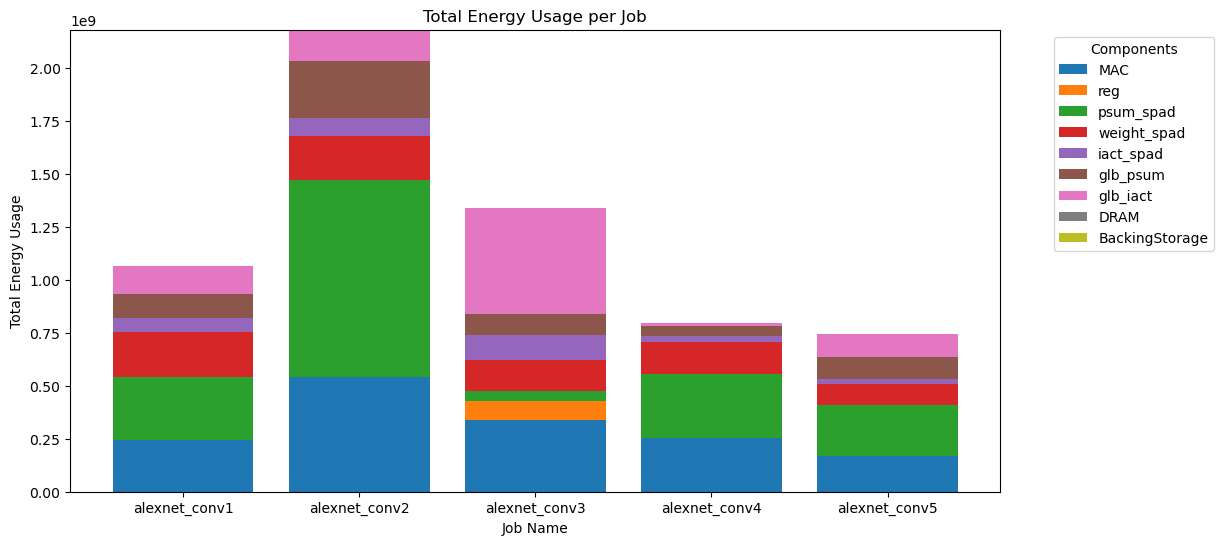

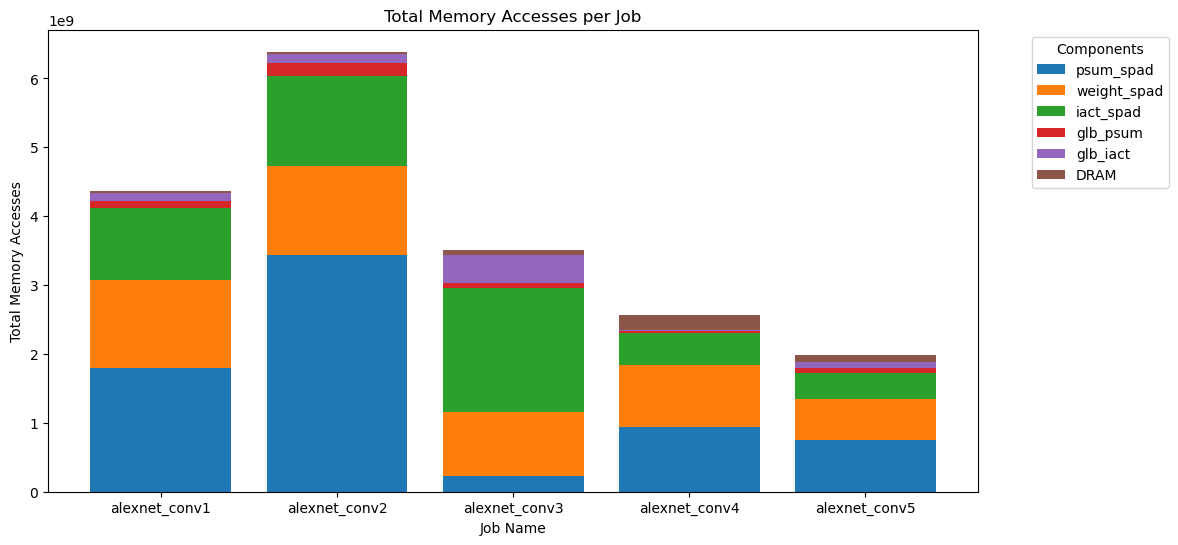

In [2]:
from IPython.display import Image
# display(Image("../evaluation_setups/Eyeriss_v2/outputs/alexnet_conv5/output/energy_breakdown_plot.png"))
display(Image("../evaluation_setups/Eyeriss_v2/outputs/alexnet_conv5/output/total_energy_plot.png"))
display(Image("../evaluation_setups/Eyeriss_v2/outputs/alexnet_conv5/output/total_memory_plot.png"))

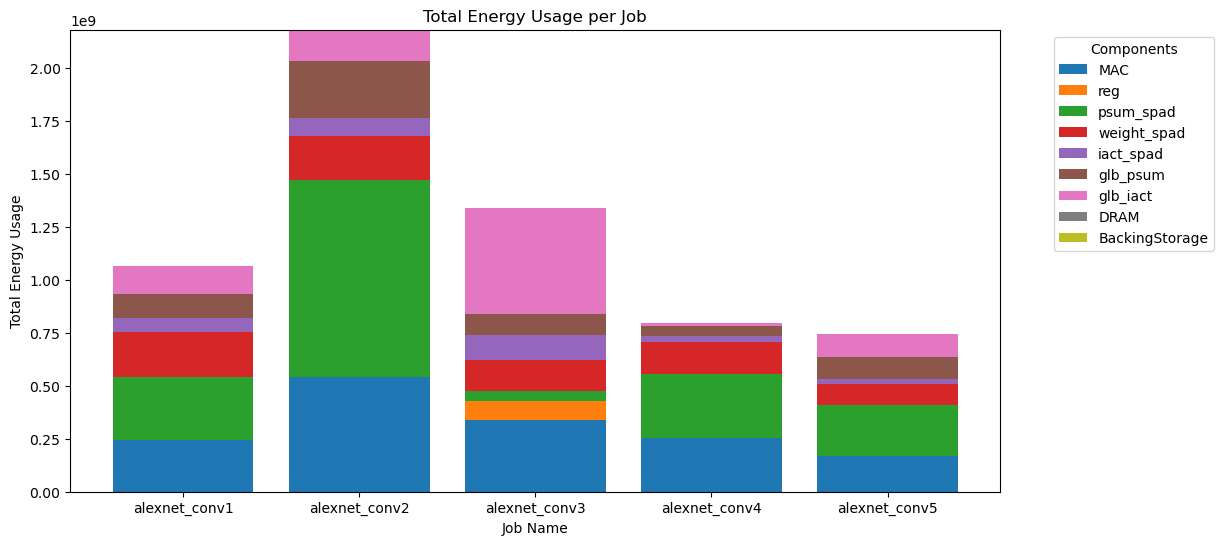

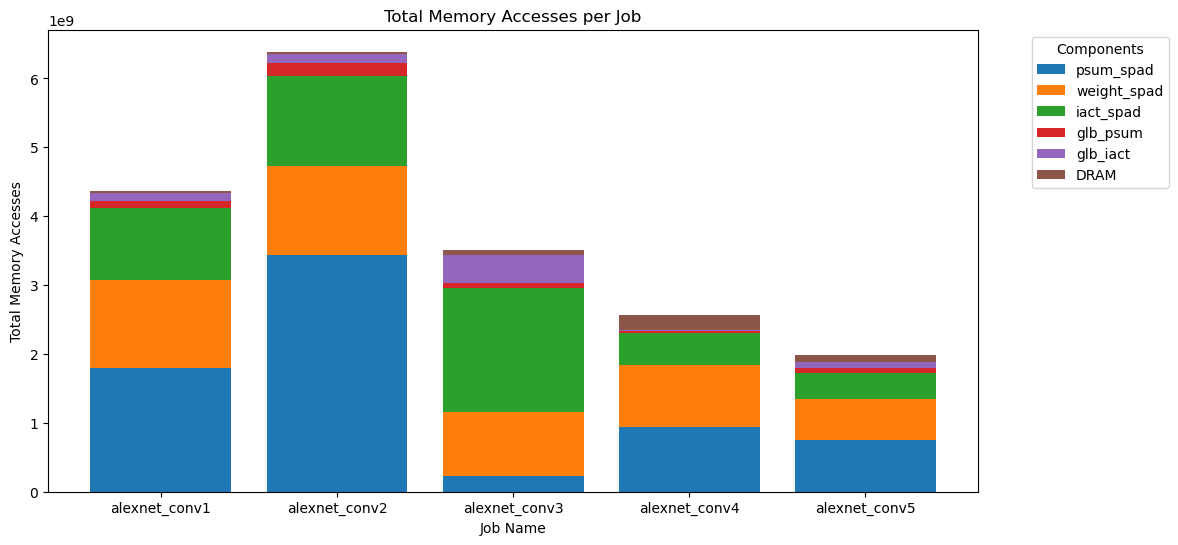

In [9]:
from IPython.display import Image
# display(Image("../evaluation_setups/Eyeriss_v2/outputs/alexnet_conv5/output/energy_breakdown_plot.png"))
display(Image("../evaluation_setups/Eyeriss_v2/outputs/alexnet_conv5/output/total_energy_plot.png"))
display(Image("../evaluation_setups/Eyeriss_v2/outputs/alexnet_conv5/output/total_memory_plot.png"))

In [2]:
%%bash
cd ../evaluation_setups/Eyeriss_v2/scripts
python3 parse_and_plot.py --stats_prefix timeloop-mapper --output_dir "outputs_single_gate"

Eyeriss DRAM Compression Ratioes (read + write)
Saved: /home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs_single_gate/alexnet_conv5/output/energy_breakdown_plot.png
Saved: /home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs_single_gate/alexnet_conv5/output/total_energy_plot.png
/home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs_single_gate/alexnet_conv5
Saved: /home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs_single_gate/alexnet_conv5/output/total_memory_plot.png


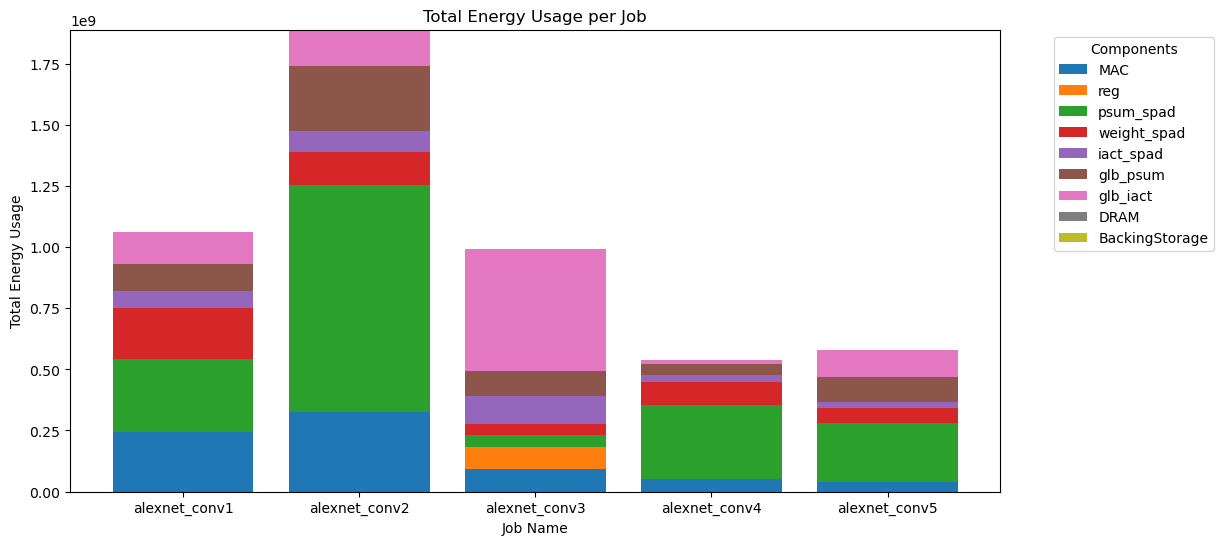

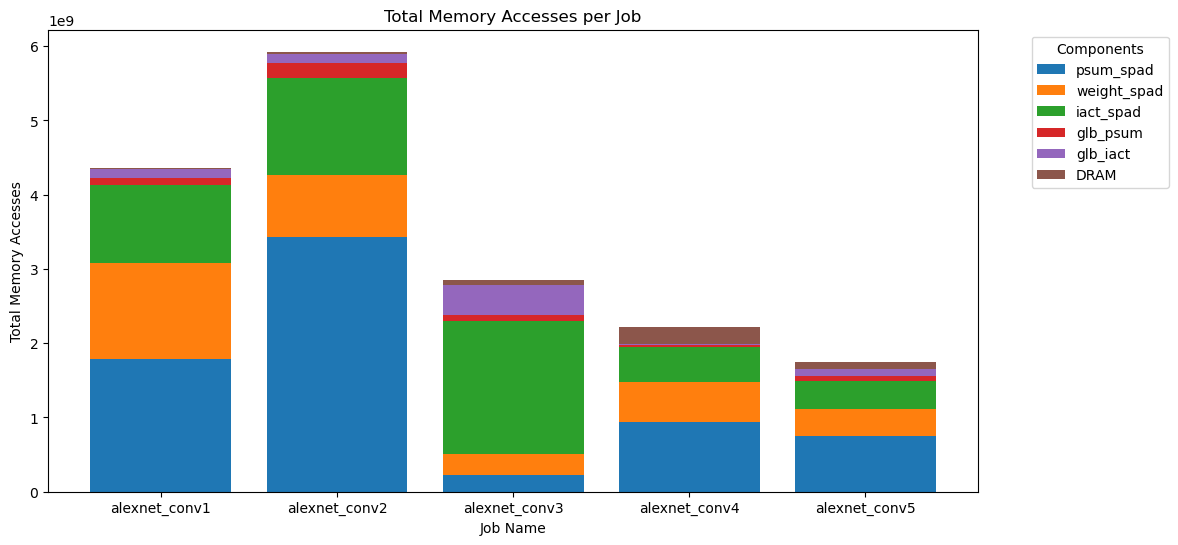

In [3]:
from IPython.display import Image
display(Image("../evaluation_setups/Eyeriss_v2/outputs_single_gate/alexnet_conv5/output/total_energy_plot.png"))
display(Image("../evaluation_setups/Eyeriss_v2/outputs_single_gate/alexnet_conv5/output/total_memory_plot.png"))

In [11]:
%%bash
cd ../evaluation_setups/Eyeriss_v2/scripts
python3 parse_and_plot.py --stats_prefix timeloop-mapper --output_dir "outputs_double_gate"

Eyeriss DRAM Compression Ratioes (read + write)
Saved: /home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs_double_gate/alexnet_conv5/output/energy_breakdown_plot.png
Saved: /home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs_double_gate/alexnet_conv5/output/total_energy_plot.png
/home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs_double_gate/alexnet_conv5
Saved: /home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs_double_gate/alexnet_conv5/output/total_memory_plot.png


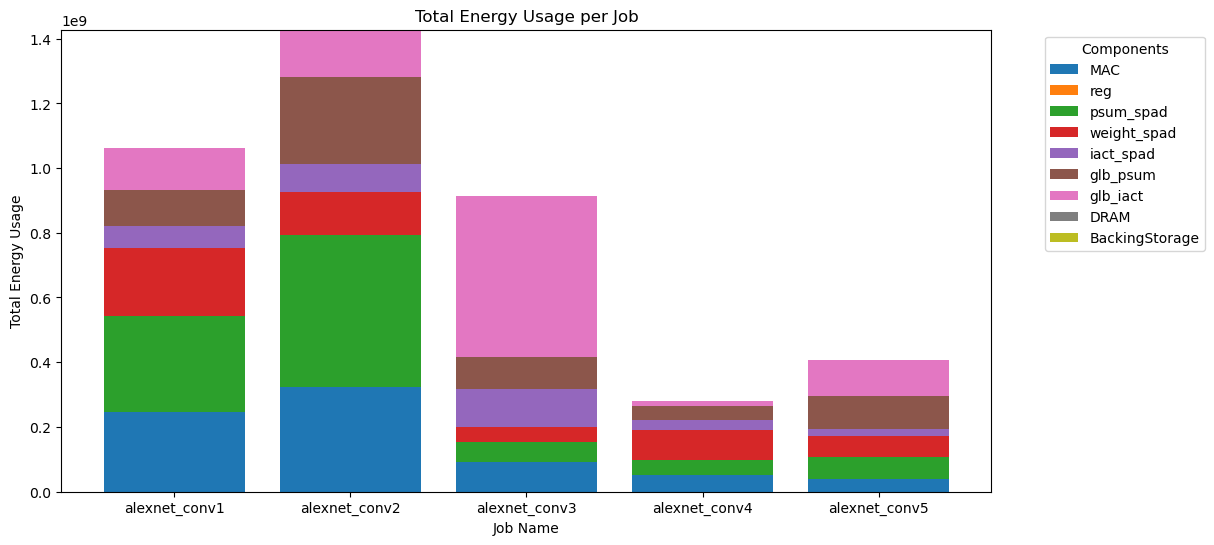

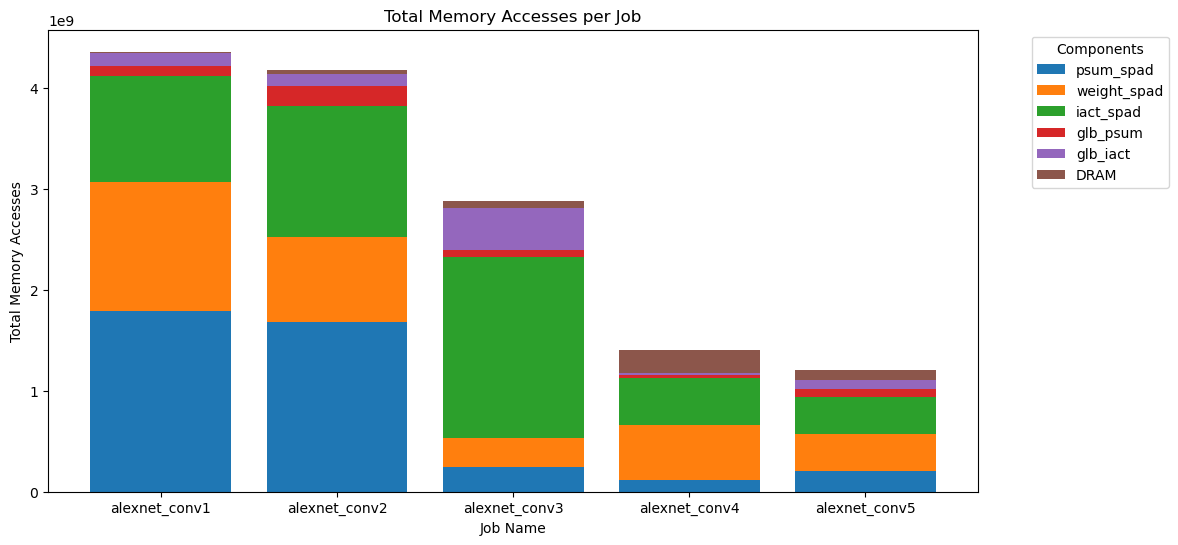

In [12]:
from IPython.display import Image
display(Image("../evaluation_setups/Eyeriss_v2/outputs_double_gate/alexnet_conv5/output/total_energy_plot.png"))
display(Image("../evaluation_setups/Eyeriss_v2/outputs_double_gate/alexnet_conv5/output/total_memory_plot.png"))

In [4]:
%%bash
cd ../evaluation_setups/Eyeriss_v2/scripts
python3 parse_and_plot.py --stats_prefix timeloop-mapper --workload_path workload_mobilenet

Eyeriss DRAM Compression Ratioes (read + write)
Saved: /home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs/mobilenet_conv8/output/energy_breakdown_plot.png
Saved: /home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs/mobilenet_conv8/output/total_energy_plot.png
/home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs/mobilenet_conv8
Saved: /home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs/mobilenet_conv8/output/total_memory_plot.png


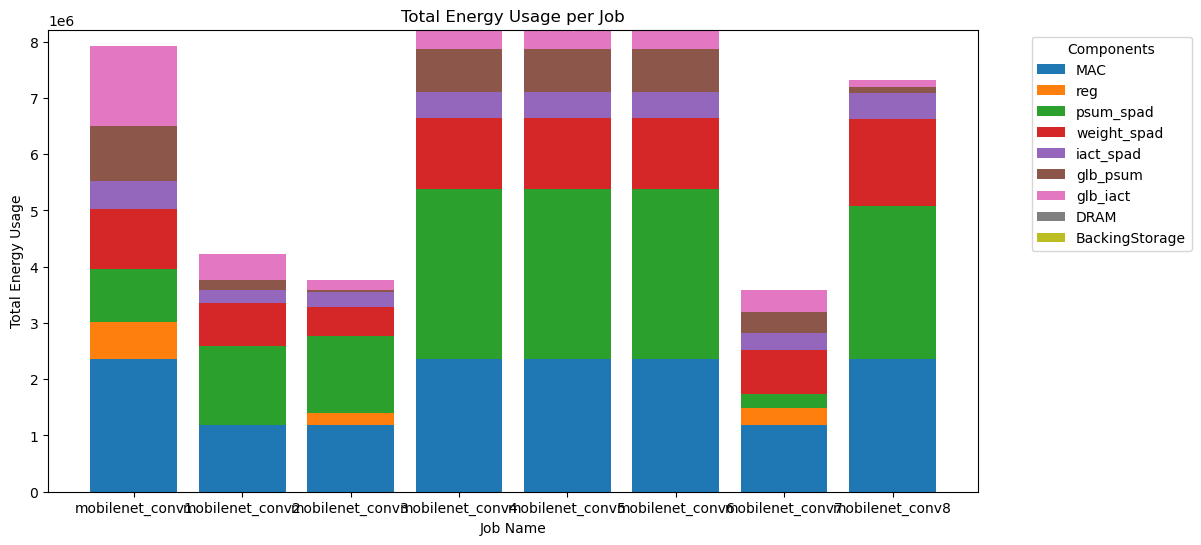

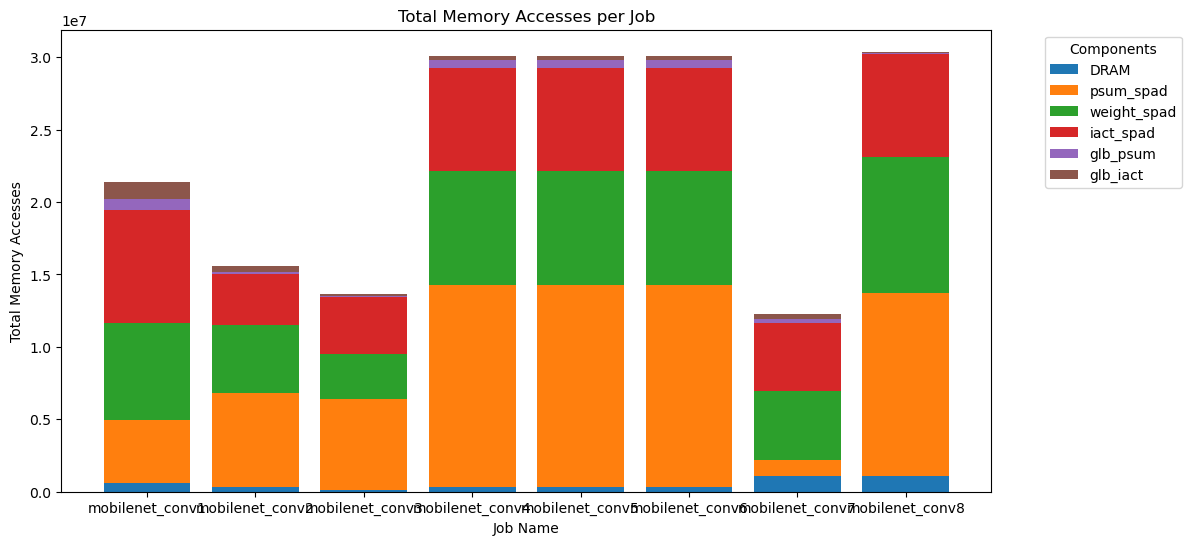

In [5]:
from IPython.display import Image
display(Image("../evaluation_setups/Eyeriss_v2/outputs/mobilenet_conv8/output/total_energy_plot.png"))
display(Image("../evaluation_setups/Eyeriss_v2/outputs/mobilenet_conv8/output/total_memory_plot.png"))

In [17]:
%%bash
cd ../evaluation_setups/Eyeriss_v2/scripts
python3 parse_and_plot.py --stats_prefix timeloop-mapper --workload_path workload_mobilenet --output_dir "outputs_single_gate"

bash: line 2:  1998 Segmentation fault      (core dumped) python3 parse_and_plot.py --stats_prefix timeloop-mapper --workload_path workload_mobilenet --output_dir "outputs_single_gate"


CalledProcessError: Command 'b'cd ../evaluation_setups/Eyeriss_v2/scripts\npython3 parse_and_plot.py --stats_prefix timeloop-mapper --workload_path workload_mobilenet --output_dir "outputs_single_gate"\n'' returned non-zero exit status 139.

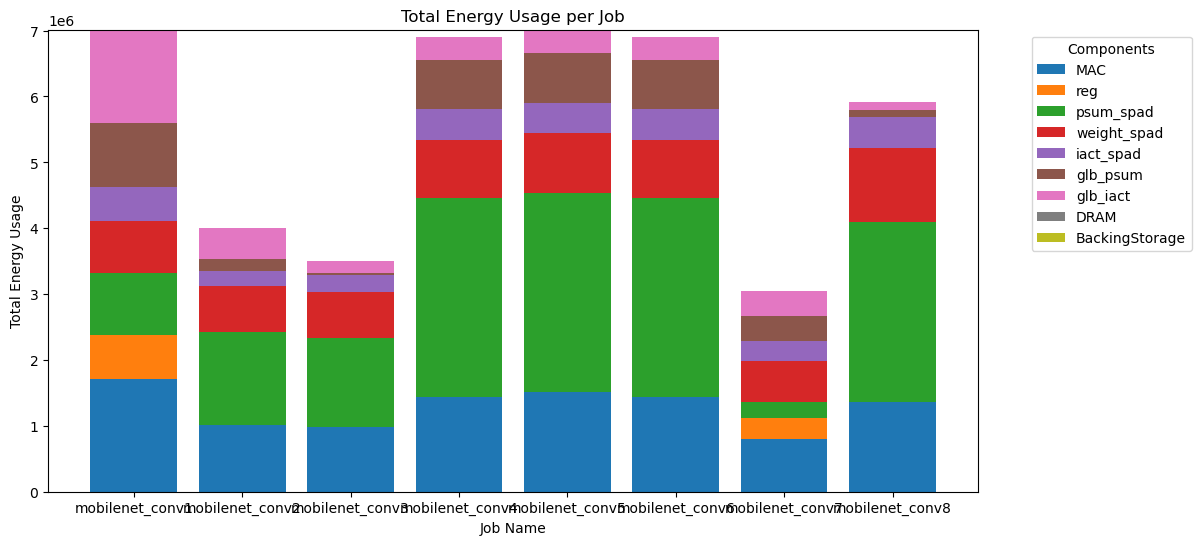

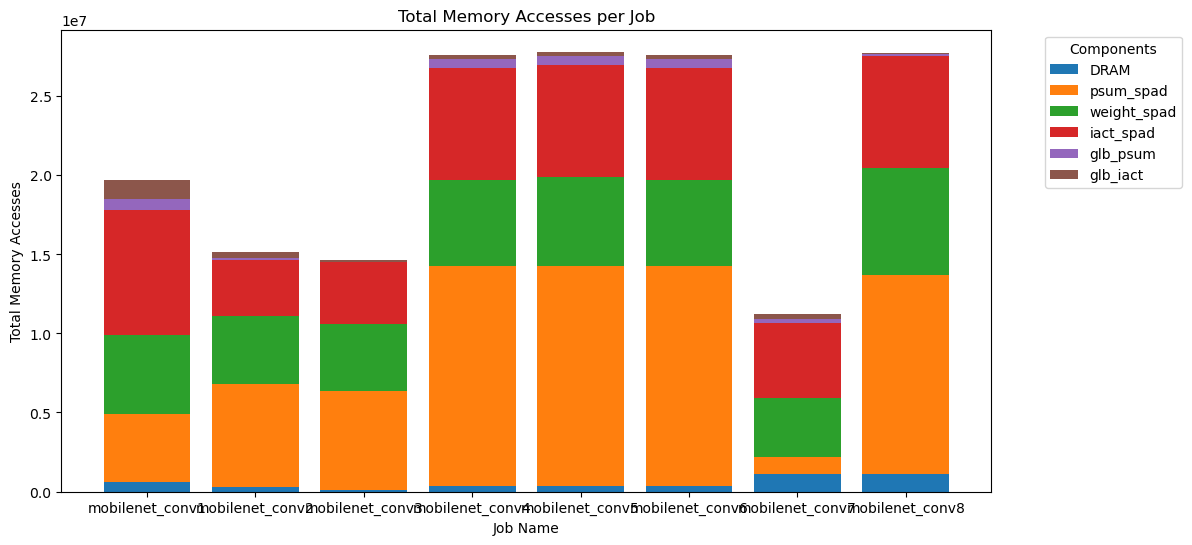

In [62]:
from IPython.display import Image
display(Image("../evaluation_setups/Eyeriss_v2/outputs_single_gate/mobilenet_conv8/output/total_energy_plot.png"))
display(Image("../evaluation_setups/Eyeriss_v2/outputs_single_gate/mobilenet_conv8/output/total_memory_plot.png"))

In [8]:
import matplotlib.pyplot as plt

In [9]:
%%bash
cd ../evaluation_setups/Eyeriss_v2/scripts
python3 parse_and_plot.py --stats_prefix timeloop-mapper --workload_path workload_mobilenet --output_dir "outputs_double_gate"

Eyeriss DRAM Compression Ratioes (read + write)
Saved: /home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs_double_gate/mobilenet_conv8/output/energy_breakdown_plot.png
Saved: /home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs_double_gate/mobilenet_conv8/output/total_energy_plot.png
/home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs_double_gate/mobilenet_conv8
Saved: /home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs_double_gate/mobilenet_conv8/output/total_memory_plot.png


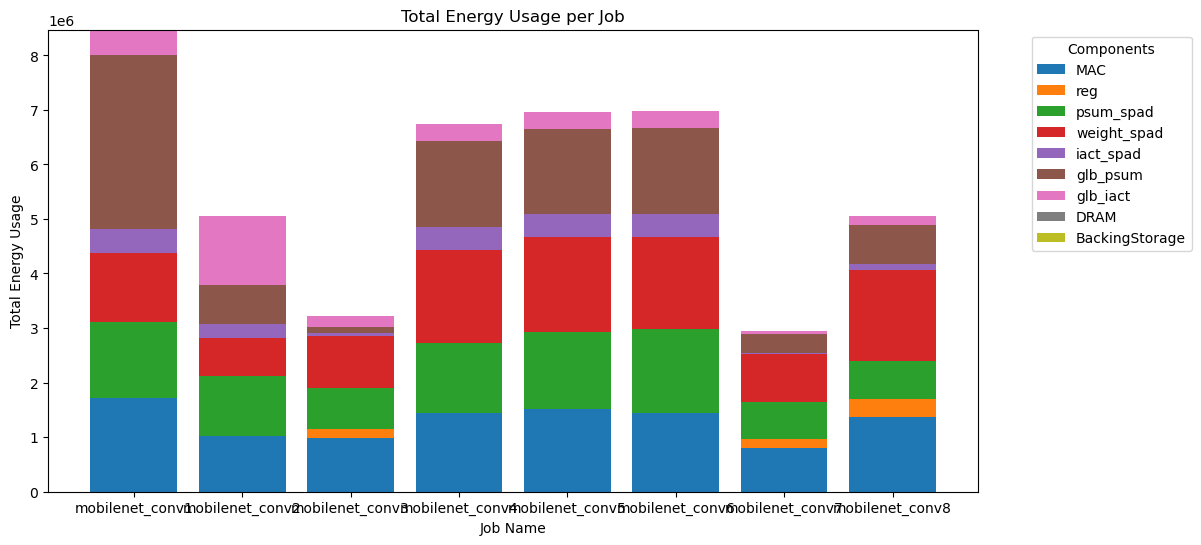

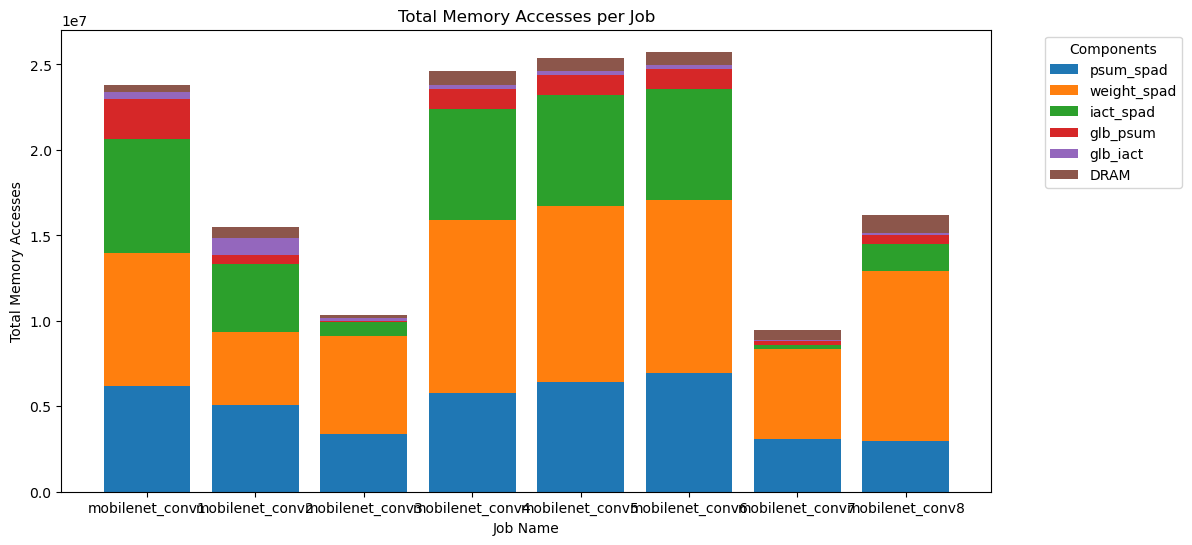

In [10]:
from IPython.display import Image
display(Image("../evaluation_setups/Eyeriss_v2/outputs_double_gate/mobilenet_conv8/output/total_energy_plot.png"))
display(Image("../evaluation_setups/Eyeriss_v2/outputs_double_gate/mobilenet_conv8/output/total_memory_plot.png"))

# Milestone 3

## High precision pass

In [6]:
%%bash
# DOUBLE GATING
cd ../evaluation_setups/Eyeriss_v2/scripts
echo "input specs at: ../evaluation_setups/Eyeriss_v2/"
time python3 sweep.py --search_mapping --output_dir "outputs_double_gate" --skip_past "alexnet_conv3.yaml"

input specs at: ../evaluation_setups/Eyeriss_v2/
  _______                __                
 /_  __(_)___ ___  ___  / /___  ____  ____ 
  / / / / __ `__ \/ _ \/ / __ \/ __ \/ __ \
 / / / / / / / / /  __/ / /_/ / /_/ / /_/ /
/_/ /_/_/ /_/ /_/\___/_/\____/\____/ .___/ 
                                  /_/      

Problem configuration complete.
Found Accelergy ERT (energy reference table), replacing internal energy model.
Found Accelergy ART (area reference table), replacing internal area model.
Architecture configuration complete.
Sparse optimization configuration complete.
Using threads = 16
Mapper configuration complete.
Initializing Index Factorization subspace.
  Factorization options along problem dimension C = 13728
  Factorization options along problem dimension M = 6435
  Factorization options along problem dimension R = 6
  Factorization options along problem dimension S = 6
  Factorization options along problem dimension N = 55
  Factorization options along problem dimension 

[  2] Utilization = 0.50 | pJ/Algorithmic-Compute =    1.559 | pJ/Compute =    6.777 | L7[WIO] M2 S3 P13 R3 - L6[] M4 C4 N2X M2X C4X - L5[I] M4 - L4[O] C2 Q13 N2X C3X - L3[I] Q1 - L2[W] Q1 - L1[O] M4 - L0[] C2 
[  0] Utilization = 0.33 | pJ/Algorithmic-Compute =    1.754 | pJ/Compute =    7.628 | L7[WIO] S3 P13 M2 R3 - L6[] M4 C4 N2X M2X C4X - L5[I] M4 - L4[O] Q13 C2 N2X C2X - L3[I] Q1 - L2[W] Q1 - L1[O] M4 - L0[] C3 
[  5] Utilization = 0.17 | pJ/Algorithmic-Compute =    1.727 | pJ/Compute =    7.510 | L7[WIO] P13 R3 M2 S3 - L6[] M4 C4 N2X M2X C4X - L5[I] M4 - L4[O] Q13 C3 N2X - L3[I] Q1 - L2[W] Q1 - L1[O] M4 - L0[] C4 
[ 12] Utilization = 0.17 | pJ/Algorithmic-Compute =    2.005 | pJ/Compute =    8.718 | L7[WIO] S3 P13 M2 R3 - L6[] M4 C4 N2X M2X C4X - L5[I] M4 - L4[O] C4 Q13 N2X - L3[I] Q1 - L2[W] C3 - L1[O] M4 - L0[] Q1 
[  7] Utilization = 0.17 | pJ/Algorithmic-Compute =    1.753 | pJ/Compute =    7.621 | L7[WIO] P13 R3 M2 S3 - L6[] M4 C4 N2X M2X C4X - L5[I] M4 - L4[O] C3 Q13 N2X -

[ 11] Utilization = 0.19 | pJ/Algorithmic-Compute =    1.788 | pJ/Compute =    7.775 | L7[WIO] C2 P13 M8 - L6[] Q13 N4 M2 M4X C3X - L5[I] M2 C2 - L4[O] R3 C4 S3X - L3[I] Q1 - L2[W] Q1 - L1[O] Q1 - L0[] M2 C4 
[  6] Utilization = 0.37 | pJ/Algorithmic-Compute =    1.742 | pJ/Compute =    7.576 | L7[WIO] C2 P13 M8 - L6[] Q13 N4 M2 M4X C3X - L5[I] C2 M2 - L4[O] R3 C2 S3X C2X - L3[I] Q1 - L2[W] C2 - L1[O] Q1 - L0[] M2 C2 
[  8] Utilization = 0.75 | pJ/Algorithmic-Compute =    1.383 | pJ/Compute =    6.015 | L7[WIO] P13 M8 C2 - L6[] Q13 N4 M2 M4X C3X - L5[I] M2 C2 - L4[O] R3 C2 S3X C4X - L3[I] Q1 - L2[W] Q1 - L1[O] Q1 - L0[] M2 C2 
[  6] Utilization = 0.37 | pJ/Algorithmic-Compute =    1.722 | pJ/Compute =    7.485 | L7[WIO] P13 M8 C2 - L6[] Q13 N4 M2 M4X C3X - L5[I] M2 C2 - L4[O] R3 C2 S3X C2X - L3[I] Q1 - L2[W] C2 - L1[O] Q1 - L0[] M2 C2 
[  4] Utilization = 1.00 | pJ/Algorithmic-Compute =    1.362 | pJ/Compute =    5.921 | L7[WIO] S3 R3 P13 M2 - L6[] M4 C4 N2X M2X C4X - L5[I] M4 - L4[O] 



Summary stats for best mapping found by mapper:
  Utilization = 1.00 | pJ/Algorithmic-Compute =    1.362 | pJ/Compute =    5.921
['alexnet_conv1.yaml', 'alexnet_conv2.yaml', 'alexnet_conv3.yaml', 'alexnet_conv4.yaml', 'alexnet_conv5.yaml']
/home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../workload_alexnet/alexnet_conv5.yaml
0.23
Running job:  alexnet_conv5
Found and overwrite existing results:  /home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs_double_gate/alexnet_conv5/output
	Running test:  alexnet_conv5



real	0m29.070s
user	5m7.864s
sys	0m0.536s


In [1]:
%%bash
cd ../evaluation_setups/Eyeriss_v2/scripts
python3 parse_and_plot.py --stats_prefix timeloop-mapper --output_dir "outputs_double_gate"

bash: line 2:   301 Segmentation fault      (core dumped) python3 parse_and_plot.py --stats_prefix timeloop-mapper --output_dir "outputs_double_gate"


Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "/usr/local/bin/conda/lib/python3.8/site-packages/IPython/core/interactiveshell.py", line 3398, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_282/457483875.py", line 1, in <cell line: 1>
    get_ipython().run_cell_magic('bash', '', 'cd ../evaluation_setups/Eyeriss_v2/scripts\npython3 parse_and_plot.py --stats_prefix timeloop-mapper --output_dir "outputs_double_gate"\n')
  File "/usr/local/bin/conda/lib/python3.8/site-packages/IPython/core/interactiveshell.py", line 2358, in run_cell_magic
    result = fn(*args, **kwargs)
  File "/usr/local/bin/conda/lib/python3.8/site-packages/IPython/core/magics/script.py", line 153, in named_script_magic
    return self.shebang(line, cell)
  File "/usr/local/bin/conda/lib/python3.8/site-packages/IPython/core/magics/script.py", line 305, in shebang
    raise CalledProcessError(rc, cell)
subprocess.CalledProcessError: Command 'b'cd ../evaluation_setups/Eyeriss_v2/scrip

In [ ]:
# Default, high-precision results
from IPython.display import Image
display(Image("../evaluation_setups/Eyeriss_v2/outputs_double_gate/alexnet_conv5/output/total_energy_plot.png"))
display(Image("../evaluation_setups/Eyeriss_v2/outputs_double_gate/alexnet_conv5/output/total_memory_plot.png"))

# Final Project

In [2]:
%%bash
cd ../evaluation_setups/Eyeriss_v2/scripts
echo "input specs at: ../evaluation_setups/Eyeriss_v2/"
time python3 sweep.py --search_mapping --output_dir "outputs_fixed_double_skip"

input specs at: ../evaluation_setups/Eyeriss_v2/
input file: /home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs_fixed_double_skip/alexnet_conv1/aggregated_input.yaml
  _______                __                
 /_  __(_)___ ___  ___  / /___  ____  ____ 
  / / / / __ `__ \/ _ \/ / __ \/ __ \/ __ \
 / / / / / / / / /  __/ / /_/ / /_/ / /_/ /
/_/ /_/_/ /_/ /_/\___/_/\____/\____/ .___/ 
                                  /_/      

Problem configuration complete.
execute:/usr/local/bin/accelergy /home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs_fixed_double_skip/alexnet_conv1/aggregated_input.yaml --oprefix timeloop-mapper. -o ./ > timeloop-mapper.accelergy.log 2>&1
Generate Accelergy ERT (energy reference table) to replace internal energy model.
Generate Accelergy ART (area reference table) to replace internal area model.
Architecture configuration complete.
Sparse optimization configuration complete.
Using threads = 16
Map

[  0] Utilization = 0.17 | pJ/Algorithmic-Compute =   12.358 | pJ/Compute =   17.419 | L6[WIO] Q2 M2 Q2X P4X - L5[I] P2 Q7 R11 M2 - L4[O] S11 M3 P7 Q2X N2X - L3[I] Q1 - L2[W] N2 - L1[O] M8 - L0[] C3  | Cycles = 9691462
[  0] Utilization = 0.17 | pJ/Algorithmic-Compute =   11.476 | pJ/Compute =   16.176 | L6[WIO] Q2 M2 Q2X P4X - L5[I] P2 Q7 R11 M2 - L4[O] S11 M3 P7 Q2X N2X - L3[I] Q1 - L2[W] N2 - L1[O] M8 - L0[O] C3  | Cycles = 9691462
[  5] STATEMENT: 3000 invalid mappings (2997 fanout, 3 capacity) found since the last valid mapping, terminating search.
[ 12] STATEMENT: 3000 invalid mappings (2995 fanout, 5 capacity) found since the last valid mapping, terminating search.
[  1] Utilization = 0.17 | pJ/Algorithmic-Compute =   21.800 | pJ/Compute =   30.728 | L6[WIO] Q2 M2 Q2X P4X - L5[I] P2 Q7 R11 M2 - L4[O] S11 M3 P7 Q2X N2X - L3[I] Q1 - L2[W] C3 N2 - L1[O] M8 - L0[] Q1  | Cycles = 9691462
[  9] STATEMENT: 3000 invalid mappings (2995 fanout, 5 capacity) found since the last valid mappi



Summary stats for best mapping found by mapper:
  Utilization = 0.50 | pJ/Algorithmic-Compute =   11.668 | pJ/Compute =   16.446 | Cycles = 3230488
input file: /home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs_fixed_double_skip/alexnet_conv2/aggregated_input.yaml
  _______                __                
 /_  __(_)___ ___  ___  / /___  ____  ____ 
  / / / / __ `__ \/ _ \/ / __ \/ __ \/ __ \
 / / / / / / / / /  __/ / /_/ / /_/ / /_/ /
/_/ /_/_/ /_/ /_/\___/_/\____/\____/ .___/ 
                                  /_/      

Problem configuration complete.
execute:/usr/local/bin/accelergy /home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs_fixed_double_skip/alexnet_conv2/aggregated_input.yaml --oprefix timeloop-mapper. -o ./ > timeloop-mapper.accelergy.log 2>&1
Generate Accelergy ERT (energy reference table) to replace internal energy model.
Generate Accelergy ART (area reference table) to replace internal area model.
Ar

[  0] STATEMENT: 3000 invalid mappings (2995 fanout, 5 capacity) found since the last valid mapping, terminating search.
[  2] STATEMENT: 3000 invalid mappings (2996 fanout, 4 capacity) found since the last valid mapping, terminating search.
[  1] STATEMENT: 3000 invalid mappings (2996 fanout, 4 capacity) found since the last valid mapping, terminating search.
[  3] STATEMENT: 3000 invalid mappings (2997 fanout, 3 capacity) found since the last valid mapping, terminating search.
[  5] STATEMENT: 3000 invalid mappings (2996 fanout, 4 capacity) found since the last valid mapping, terminating search.
[  4] STATEMENT: 3000 invalid mappings (2997 fanout, 3 capacity) found since the last valid mapping, terminating search.
[  6] STATEMENT: 3000 invalid mappings (2996 fanout, 4 capacity) found since the last valid mapping, terminating search.
[  7] STATEMENT: 3000 invalid mappings (2996 fanout, 4 capacity) found since the last valid mapping, terminating search.
[ 15] STATEMENT: 3000 invalid ma



Summary stats for best mapping found by mapper:
  Utilization = 0.29 | pJ/Algorithmic-Compute =    4.163 | pJ/Compute =   18.009 | Cycles = 3977098
input file: /home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs_fixed_double_skip/alexnet_conv3/aggregated_input.yaml
  _______                __                
 /_  __(_)___ ___  ___  / /___  ____  ____ 
  / / / / __ `__ \/ _ \/ / __ \/ __ \/ __ \
 / / / / / / / / /  __/ / /_/ / /_/ / /_/ /
/_/ /_/_/ /_/ /_/\___/_/\____/\____/ .___/ 
                                  /_/      

Problem configuration complete.
execute:/usr/local/bin/accelergy /home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs_fixed_double_skip/alexnet_conv3/aggregated_input.yaml --oprefix timeloop-mapper. -o ./ > timeloop-mapper.accelergy.log 2>&1
Generate Accelergy ERT (energy reference table) to replace internal energy model.
Generate Accelergy ART (area reference table) to replace internal area model.
Ar

...

[  0] STATEMENT: 3000 invalid mappings (2996 fanout, 4 capacity) found since the last valid mapping, terminating search.
[ 11] STATEMENT: 3000 invalid mappings (2994 fanout, 6 capacity) found since the last valid mapping, terminating search.
[  1] STATEMENT: 3000 invalid mappings (2996 fanout, 4 capacity) found since the last valid mapping, terminating search.
[ 12] STATEMENT: 3000 invalid mappings (2991 fanout, 9 capacity) found since the last valid mapping, terminating search.
[  5] Utilization = 0.06 | pJ/Algorithmic-Compute =   33.925 | pJ/Compute =  440.031 | L6[WIO] Q13 M8 M2X - L5[I] P13 M8 R3 - L4[O] C64 S3 N2X C3X - L3[I] N2 - L2[W] Q1 - L1[O] Q1 - L0[] M3  | Cycles = 2881892
[  9] STATEMENT: 3000 invalid mappings (2992 fanout, 8 capacity) found since the last valid mapping, terminating search.
[  3] Utilization = 0.02 | pJ/Algorithmic-Compute =   33.190 | pJ/Compute =  430.502 | L6[WIO] Q13 M8 M2X - L5[I] M8 R3 P13 - L4[O] S3 C64 N2X - L3[I] N2 - L2[W] Q1 - L1[O] Q1 - L0[] M3



Summary stats for best mapping found by mapper:
  Utilization = 0.25 | pJ/Algorithmic-Compute =   33.490 | pJ/Compute =  434.388 | Cycles = 720473
input file: /home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs_fixed_double_skip/alexnet_conv5/aggregated_input.yaml
  _______                __                
 /_  __(_)___ ___  ___  / /___  ____  ____ 
  / / / / __ `__ \/ _ \/ / __ \/ __ \/ __ \
 / / / / / / / / /  __/ / /_/ / /_/ / /_/ /
/_/ /_/_/ /_/ /_/\___/_/\____/\____/ .___/ 
                                  /_/      

Problem configuration complete.
execute:/usr/local/bin/accelergy /home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs_fixed_double_skip/alexnet_conv5/aggregated_input.yaml --oprefix timeloop-mapper. -o ./ > timeloop-mapper.accelergy.log 2>&1
Generate Accelergy ERT (energy reference table) to replace internal energy model.
Generate Accelergy ART (area reference table) to replace internal area model.
Arc

[  7] Utilization = 0.25 | pJ/Algorithmic-Compute =   28.320 | pJ/Compute =  333.855 | L6[WIO] M4 C4 N2X M2X C2X - L5[I] S3 C4 P13 - L4[O] Q13 M16 R3X M2X - L3[I] Q1 - L2[W] C3 - L1[O] Q1 - L0[] N2 C2  | Cycles = 528471
[  8] Utilization = 0.25 | pJ/Algorithmic-Compute =   28.320 | pJ/Compute =  333.855 | L6[WIO] M4 C4 N2X M2X C2X - L5[I] S3 C4 P13 - L4[O] Q13 M16 R3X M2X - L3[I] Q1 - L2[W] C6 - L1[O] Q1 - L0[] N2  | Cycles = 528471
[  4] Utilization = 0.25 | pJ/Algorithmic-Compute =   32.688 | pJ/Compute =  385.352 | L6[WIO] M4 C4 N2X M2X C2X - L5[I] C3 S3 P13 - L4[O] Q13 C8 M16 R3X M2X - L3[I] Q1 - L2[W] Q1 - L1[O] Q1 - L0[] N2  | Cycles = 528471
[  9] Utilization = 0.50 | pJ/Algorithmic-Compute =   28.282 | pJ/Compute =  333.405 | L6[WIO] M4 C4 N2X M2X C2X - L5[I] S3 C4 P13 - L4[O] Q13 M16 R3X M2X C2X - L3[I] Q1 - L2[W] Q1 - L1[O] Q1 - L0[] N2 C3  | Cycles = 264236
[ 10] Utilization = 0.50 | pJ/Algorithmic-Compute =   28.282 | pJ/Compute =  333.405 | L6[WIO] M4 C4 N2X M2X C2X - L5[I



Summary stats for best mapping found by mapper:
  Utilization = 0.75 | pJ/Algorithmic-Compute =    5.500 | pJ/Compute =   64.843 | Cycles = 176157
['alexnet_conv1.yaml', 'alexnet_conv2.yaml', 'alexnet_conv3.yaml', 'alexnet_conv4.yaml', 'alexnet_conv5.yaml']
/home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../workload_alexnet/alexnet_conv1.yaml
0.999
Running job:  alexnet_conv1
Found and overwrite existing results:  /home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs_fixed_double_skip/alexnet_conv1/output
	Running test:  alexnet_conv1
/home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../workload_alexnet/alexnet_conv2.yaml
0.6
Running job:  alexnet_conv2
Found and overwrite existing results:  /home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs_fixed_double_skip/alexnet_conv2/output
	Running test:  alexnet_conv2
/home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/s


real	0m57.715s
user	5m34.997s
sys	0m1.167s


In [1]:
%%bash
cd ../evaluation_setups/Eyeriss_v2/scripts
echo "input specs at: ../evaluation_setups/Eyeriss_v2/"
time python3 sweep.py --search_mapping --output_dir "outputs_fixed_no_skip"

input specs at: ../evaluation_setups/Eyeriss_v2/
input file: /home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs_fixed_no_skip/alexnet_conv1/aggregated_input.yaml
  _______                __                
 /_  __(_)___ ___  ___  / /___  ____  ____ 
  / / / / __ `__ \/ _ \/ / __ \/ __ \/ __ \
 / / / / / / / / /  __/ / /_/ / /_/ / /_/ /
/_/ /_/_/ /_/ /_/\___/_/\____/\____/ .___/ 
                                  /_/      

Problem configuration complete.
execute:/usr/local/bin/accelergy /home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs_fixed_no_skip/alexnet_conv1/aggregated_input.yaml --oprefix timeloop-mapper. -o ./ > timeloop-mapper.accelergy.log 2>&1
Generate Accelergy ERT (energy reference table) to replace internal energy model.
Generate Accelergy ART (area reference table) to replace internal area model.
Architecture configuration complete.
Sparse optimization configuration complete.
Using threads = 16
Mapper conf

[  0] Utilization = 0.17 | pJ/Algorithmic-Compute =   13.684 | pJ/Compute =   13.684 | L6[WIO] Q2 M2 Q2X P4X - L5[I] P2 Q7 R11 M2 - L4[O] S11 M3 P7 Q2X N2X - L3[I] Q1 - L2[W] N2 - L1[O] M8 - L0[] C3  | Cycles = 13660416
[  0] Utilization = 0.17 | pJ/Algorithmic-Compute =   12.092 | pJ/Compute =   12.092 | L6[WIO] Q2 M2 Q2X P4X - L5[I] P2 Q7 R11 M2 - L4[O] S11 M3 P7 Q2X N2X - L3[I] Q1 - L2[W] N2 - L1[O] M8 - L0[O] C3  | Cycles = 13660416
[  1] Utilization = 0.17 | pJ/Algorithmic-Compute =   23.126 | pJ/Compute =   23.126 | L6[WIO] Q2 M2 Q2X P4X - L5[I] P2 Q7 R11 M2 - L4[O] S11 M3 P7 Q2X N2X - L3[I] Q1 - L2[W] C3 N2 - L1[O] M8 - L0[] Q1  | Cycles = 13660416
[  2] Utilization = 0.50 | pJ/Algorithmic-Compute =   14.260 | pJ/Compute =   14.260 | L6[WIO] Q2 M2 Q2X P4X - L5[I] R11 P2 M2 Q7 - L4[O] S11 M3 P7 Q2X N2X C3X - L3[I] Q1 - L2[W] N2 - L1[O] M8 - L0[] Q1  | Cycles = 4553472
[  1] Utilization = 0.17 | pJ/Algorithmic-Compute =   23.038 | pJ/Compute =   23.038 | L6[WIO] Q2 M2 Q2X P4X - L5



Summary stats for best mapping found by mapper:
  Utilization = 0.50 | pJ/Algorithmic-Compute =   12.903 | pJ/Compute =   12.903 | Cycles = 4553472
input file: /home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs_fixed_no_skip/alexnet_conv2/aggregated_input.yaml
  _______                __                
 /_  __(_)___ ___  ___  / /___  ____  ____ 
  / / / / __ `__ \/ _ \/ / __ \/ __ \/ __ \
 / / / / / / / / /  __/ / /_/ / /_/ / /_/ /
/_/ /_/_/ /_/ /_/\___/_/\____/\____/ .___/ 
                                  /_/      

Problem configuration complete.
execute:/usr/local/bin/accelergy /home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs_fixed_no_skip/alexnet_conv2/aggregated_input.yaml --oprefix timeloop-mapper. -o ./ > timeloop-mapper.accelergy.log 2>&1
Generate Accelergy ERT (energy reference table) to replace internal energy model.
Generate Accelergy ART (area reference table) to replace internal area model.
Architectu

[  3] STATEMENT: 3000 invalid mappings (2997 fanout, 3 capacity) found since the last valid mapping, terminating search.
[  0] STATEMENT: 3000 invalid mappings (2995 fanout, 5 capacity) found since the last valid mapping, terminating search.
[  1] STATEMENT: 3000 invalid mappings (2996 fanout, 4 capacity) found since the last valid mapping, terminating search.
[  6] STATEMENT: 3000 invalid mappings (2996 fanout, 4 capacity) found since the last valid mapping, terminating search.
[  5] STATEMENT: 3000 invalid mappings (2996 fanout, 4 capacity) found since the last valid mapping, terminating search.
[  2] STATEMENT: 3000 invalid mappings (2996 fanout, 4 capacity) found since the last valid mapping, terminating search.
[ 14] STATEMENT: 3000 invalid mappings (2995 fanout, 5 capacity) found since the last valid mapping, terminating search.
[ 13] STATEMENT: 3000 invalid mappings (2996 fanout, 4 capacity) found since the last valid mapping, terminating search.
[ 12] STATEMENT: 3000 invalid ma



Summary stats for best mapping found by mapper:
  Utilization = 0.29 | pJ/Algorithmic-Compute =    7.893 | pJ/Compute =    7.893 | Cycles = 17203200
input file: /home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs_fixed_no_skip/alexnet_conv3/aggregated_input.yaml
  _______                __                
 /_  __(_)___ ___  ___  / /___  ____  ____ 
  / / / / __ `__ \/ _ \/ / __ \/ __ \/ __ \
 / / / / / / / / /  __/ / /_/ / /_/ / /_/ /
/_/ /_/_/ /_/ /_/\___/_/\____/\____/ .___/ 
                                  /_/      

Problem configuration complete.
execute:/usr/local/bin/accelergy /home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs_fixed_no_skip/alexnet_conv3/aggregated_input.yaml --oprefix timeloop-mapper. -o ./ > timeloop-mapper.accelergy.log 2>&1
Generate Accelergy ERT (energy reference table) to replace internal energy model.
Generate Accelergy ART (area reference table) to replace internal area model.
Architect

[  8] Utilization = 0.08 | pJ/Algorithmic-Compute =   61.575 | pJ/Compute =   61.575 | L6[WIO] C8 M8X - L5[I] M2 R3 - L4[O] Q13 P13 C32 N2 M3 N2X - L3[I] Q1 - L2[W] Q1 - L1[O] Q1 - L0[] S3 M8  | Cycles = 37380096
[  4] Utilization = 0.08 | pJ/Algorithmic-Compute =    7.604 | pJ/Compute =    7.604 | L6[WIO] C8 M8X - L5[I] M2 R3 - L4[O] C8 M3 N2 Q13 P13 N2X - L3[I] Q1 - L2[W] C4 - L1[O] Q1 - L0[] S3 M8  | Cycles = 37380096
[  3] Utilization = 0.08 | pJ/Algorithmic-Compute =   58.523 | pJ/Compute =   58.523 | L6[WIO] C8 M8X - L5[I] R3 M2 - L4[O] C8 N2 Q13 P13 M3 N2X - L3[I] Q1 - L2[W] C2 - L1[O] Q1 - L0[] S3 M8 C2  | Cycles = 37380096
[  7] Utilization = 0.33 | pJ/Algorithmic-Compute =   33.331 | pJ/Compute =   33.331 | L6[WIO] C8 M8X - L5[I] M2 R3 - L4[O] C8 P13 Q13 M3 N2 N2X C4X - L3[I] Q1 - L2[W] Q1 - L1[O] Q1 - L0[] S3 M8  | Cycles = 9345024
[  0] Utilization = 0.33 | pJ/Algorithmic-Compute =   33.076 | pJ/Compute =   33.076 | L6[WIO] C8 M8X - L5[I] R3 M2 - L4[O] Q13 M3 P13 C4 N2 N2X 



Summary stats for best mapping found by mapper:
  Utilization = 0.38 | pJ/Algorithmic-Compute =   11.980 | pJ/Compute =   11.980 | Cycles = 8306688
input file: /home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs_fixed_no_skip/alexnet_conv4/aggregated_input.yaml
  _______                __                
 /_  __(_)___ ___  ___  / /___  ____  ____ 
  / / / / __ `__ \/ _ \/ / __ \/ __ \/ __ \
 / / / / / / / / /  __/ / /_/ / /_/ / /_/ /
/_/ /_/_/ /_/ /_/\___/_/\____/\____/ .___/ 
                                  /_/      

Problem configuration complete.
execute:/usr/local/bin/accelergy /home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs_fixed_no_skip/alexnet_conv4/aggregated_input.yaml --oprefix timeloop-mapper. -o ./ > timeloop-mapper.accelergy.log 2>&1
Failed to run Accelergy. Did you install Accelergy or specify ACCELERGYPATH correctly? Or check accelergy.log to see what went wrong
input file: /home/workspace/2022.micr

[  5] Utilization = 0.25 | pJ/Algorithmic-Compute =   32.919 | pJ/Compute =   32.919 | L6[WIO] M4 C4 N2X M2X C2X - L5[I] S3 C4 P13 - L4[O] Q13 M16 R3X M2X - L3[I] Q1 - L2[W] Q1 - L1[O] Q1 - L0[] N2 C6  | Cycles = 6230016
[  4] Utilization = 0.25 | pJ/Algorithmic-Compute =   37.288 | pJ/Compute =   37.288 | L6[WIO] M4 C4 N2X M2X C2X - L5[I] C3 S3 P13 - L4[O] Q13 C8 M16 R3X M2X - L3[I] Q1 - L2[W] Q1 - L1[O] Q1 - L0[] N2  | Cycles = 6230016
[  4] Utilization = 0.25 | pJ/Algorithmic-Compute =   37.012 | pJ/Compute =   37.012 | L6[WIO] M4 C4 N2X M2X C2X - L5[I] C3 S3 P13 - L4[O] Q13 C8 M16 R3X M2X - L3[I] Q1 - L2[W] Q1 - L1[O] Q1 - L0[W] N2  | Cycles = 6230016
[ 15] Utilization = 0.25 | pJ/Algorithmic-Compute =   36.212 | pJ/Compute =   36.212 | L6[WIO] M4 C4 N2X M2X C2X - L5[I] C4 S3 P13 - L4[O] Q13 M16 C2 R3X M2X - L3[I] Q1 - L2[W] C3 - L1[O] Q1 - L0[] N2  | Cycles = 6230016
[  2] Utilization = 0.25 | pJ/Algorithmic-Compute =   34.519 | pJ/Compute =   34.519 | L6[WIO] M4 C4 N2X M2X C2X - 



Summary stats for best mapping found by mapper:
  Utilization = 0.75 | pJ/Algorithmic-Compute =    9.784 | pJ/Compute =    9.784 | Cycles = 2076672
['alexnet_conv1.yaml', 'alexnet_conv2.yaml', 'alexnet_conv3.yaml', 'alexnet_conv4.yaml', 'alexnet_conv5.yaml']
/home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../workload_alexnet/alexnet_conv1.yaml
0.999
Running job:  alexnet_conv1
Found and overwrite existing results:  /home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs_fixed_no_skip/alexnet_conv1/output
	Running test:  alexnet_conv1
/home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../workload_alexnet/alexnet_conv2.yaml
0.6
Running job:  alexnet_conv2
Found and overwrite existing results:  /home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs_fixed_no_skip/alexnet_conv2/output
	Running test:  alexnet_conv2
/home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/


real	0m49.168s
user	5m8.640s
sys	0m1.238s


In [2]:
%%bash
cd ../evaluation_setups/Eyeriss_v2/scripts
echo "input specs at: ../evaluation_setups/Eyeriss_v2/"
time python3 sweep.py --search_mapping --output_dir "outputs_sparse_double_skip"

input specs at: ../evaluation_setups/Eyeriss_v2/
input file: /home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs_sparse_double_skip/alexnet_conv1/aggregated_input.yaml
  _______                __                
 /_  __(_)___ ___  ___  / /___  ____  ____ 
  / / / / __ `__ \/ _ \/ / __ \/ __ \/ __ \
 / / / / / / / / /  __/ / /_/ / /_/ / /_/ /
/_/ /_/_/ /_/ /_/\___/_/\____/\____/ .___/ 
                                  /_/      

Problem configuration complete.
execute:/usr/local/bin/accelergy /home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs_sparse_double_skip/alexnet_conv1/aggregated_input.yaml --oprefix timeloop-mapper. -o ./ > timeloop-mapper.accelergy.log 2>&1
Generate Accelergy ERT (energy reference table) to replace internal energy model.
Generate Accelergy ART (area reference table) to replace internal area model.
Architecture configuration complete.
Sparse optimization configuration complete.
Using threads = 16
M

[  5] STATEMENT: 3000 invalid mappings (2997 fanout, 3 capacity) found since the last valid mapping, terminating search.
[  7] Utilization = 0.30 | pJ/Algorithmic-Compute =    8.509 | pJ/Compute =  850.896 | L6[WIO] Q2 M2 Q2X P4X - L5[I] P2 Q7 R11 M2 - L4[O] S11 M3 P7 Q2X N2X M2X - L3[I] Q1 - L2[W] N2 - L1[O] Q1 - L0[] M4 C3  | Cycles = 77028
[  0] Utilization = 0.17 | pJ/Algorithmic-Compute =    8.485 | pJ/Compute =  848.463 | L6[WIO] Q2 M2 Q2X P4X - L5[I] P2 Q7 R11 M2 - L4[O] S11 M3 P7 Q2X N2X - L3[I] Q1 - L2[W] N2 - L1[O] M8 - L0[] C3  | Cycles = 136605
[  9] STATEMENT: 3000 invalid mappings (2995 fanout, 5 capacity) found since the last valid mapping, terminating search.
[  8] Utilization = 0.10 | pJ/Algorithmic-Compute =   17.952 | pJ/Compute = 1795.166 | L6[WIO] Q2 M2 Q2X P4X - L5[I] P2 Q7 R11 M2 - L4[O] S11 M3 P7 Q2X N2X M2X - L3[I] Q1 - L2[W] C3 N2 - L1[O] Q1 - L0[] M4  | Cycles = 219325
[  1] Utilization = 0.10 | pJ/Algorithmic-Compute =   17.927 | pJ/Compute = 1792.733 | L6[W



Summary stats for best mapping found by mapper:
  Utilization = 0.32 | pJ/Algorithmic-Compute =    7.389 | pJ/Compute =  738.887 | Cycles = 71148
input file: /home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs_sparse_double_skip/alexnet_conv2/aggregated_input.yaml
  _______                __                
 /_  __(_)___ ___  ___  / /___  ____  ____ 
  / / / / __ `__ \/ _ \/ / __ \/ __ \/ __ \
 / / / / / / / / /  __/ / /_/ / /_/ / /_/ /
/_/ /_/_/ /_/ /_/\___/_/\____/\____/ .___/ 
                                  /_/      

Problem configuration complete.
execute:/usr/local/bin/accelergy /home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs_sparse_double_skip/alexnet_conv2/aggregated_input.yaml --oprefix timeloop-mapper. -o ./ > timeloop-mapper.accelergy.log 2>&1
Generate Accelergy ERT (energy reference table) to replace internal energy model.
Generate Accelergy ART (area reference table) to replace internal area model.
Ar

[  1] STATEMENT: 3000 invalid mappings (2996 fanout, 4 capacity) found since the last valid mapping, terminating search.
[  2] STATEMENT: 3000 invalid mappings (2996 fanout, 4 capacity) found since the last valid mapping, terminating search.
[ 15] STATEMENT: 3000 invalid mappings (2995 fanout, 5 capacity) found since the last valid mapping, terminating search.
[ 12] STATEMENT: 3000 invalid mappings (2995 fanout, 5 capacity) found since the last valid mapping, terminating search.
[  4] STATEMENT: 3000 invalid mappings (2997 fanout, 3 capacity) found since the last valid mapping, terminating search.
[  6] STATEMENT: 3000 invalid mappings (2996 fanout, 4 capacity) found since the last valid mapping, terminating search.
[ 14] STATEMENT: 3000 invalid mappings (2995 fanout, 5 capacity) found since the last valid mapping, terminating search.
[  9] Utilization = 0.27 | pJ/Algorithmic-Compute =    7.750 | pJ/Compute =  774.981 | L6[WIO] C2 Q7X - L5[I] R5 M4 - L4[O] N2 P28 M2 C4 S5 Q4X M2X - L3[



Summary stats for best mapping found by mapper:
  Utilization = 0.29 | pJ/Algorithmic-Compute =    2.830 | pJ/Compute =  283.039 | Cycles = 172032
input file: /home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs_sparse_double_skip/alexnet_conv3/aggregated_input.yaml
  _______                __                
 /_  __(_)___ ___  ___  / /___  ____  ____ 
  / / / / __ `__ \/ _ \/ / __ \/ __ \/ __ \
 / / / / / / / / /  __/ / /_/ / /_/ / /_/ /
/_/ /_/_/ /_/ /_/\___/_/\____/\____/ .___/ 
                                  /_/      

Problem configuration complete.
execute:/usr/local/bin/accelergy /home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs_sparse_double_skip/alexnet_conv3/aggregated_input.yaml --oprefix timeloop-mapper. -o ./ > timeloop-mapper.accelergy.log 2>&1
Generate Accelergy ERT (energy reference table) to replace internal energy model.
Generate Accelergy ART (area reference table) to replace internal area model.
A

...

[  6] STATEMENT: 3000 invalid mappings (2993 fanout, 7 capacity) found since the last valid mapping, terminating search.
[  3] Utilization = 0.02 | pJ/Algorithmic-Compute =   32.792 | pJ/Compute = 3279.193 | L6[WIO] Q13 M8 M2X - L5[I] M8 R3 P13 - L4[O] S3 C64 N2X - L3[I] N2 - L2[W] Q1 - L1[O] Q1 - L0[] M3 C3  | Cycles = 1121403
[  4] Utilization = 0.02 | pJ/Algorithmic-Compute =   32.712 | pJ/Compute = 3271.240 | L6[WIO] Q13 M8 M2X - L5[I] P13 M8 R3 - L4[O] C64 S3 N2X - L3[I] N2 - L2[W] C3 - L1[O] Q1 - L0[] M3  | Cycles = 1121403
[  5] Utilization = 0.06 | pJ/Algorithmic-Compute =   33.527 | pJ/Compute = 3352.664 | L6[WIO] Q13 M8 M2X - L5[I] P13 M8 R3 - L4[O] C64 S3 N2X C3X - L3[I] N2 - L2[W] Q1 - L1[O] Q1 - L0[] M3  | Cycles = 389376
[  1] STATEMENT: 3000 invalid mappings (2996 fanout, 4 capacity) found since the last valid mapping, terminating search.
[  2] STATEMENT: 3000 invalid mappings (2995 fanout, 5 capacity) found since the last valid mapping, terminating search.
[ 11] STATEME



Summary stats for best mapping found by mapper:
  Utilization = 0.25 | pJ/Algorithmic-Compute =   52.529 | pJ/Compute = 5252.880 | Cycles = 93451
input file: /home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs_sparse_double_skip/alexnet_conv5/aggregated_input.yaml
  _______                __                
 /_  __(_)___ ___  ___  / /___  ____  ____ 
  / / / / __ `__ \/ _ \/ / __ \/ __ \/ __ \
 / / / / / / / / /  __/ / /_/ / /_/ / /_/ /
/_/ /_/_/ /_/ /_/\___/_/\____/\____/ .___/ 
                                  /_/      

Problem configuration complete.
execute:/usr/local/bin/accelergy /home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs_sparse_double_skip/alexnet_conv5/aggregated_input.yaml --oprefix timeloop-mapper. -o ./ > timeloop-mapper.accelergy.log 2>&1
Generate Accelergy ERT (energy reference table) to replace internal energy model.
Generate Accelergy ART (area reference table) to replace internal area model.
Ar

[  2] Utilization = 0.25 | pJ/Algorithmic-Compute =   29.448 | pJ/Compute = 2944.777 | L6[WIO] M4 C4 N2X M2X C2X - L5[I] S3 C3 P13 - L4[O] C4 Q13 M16 R3X M2X - L3[I] Q1 - L2[W] C2 - L1[O] Q1 - L0[] N2  | Cycles = 62301
[  6] Utilization = 0.25 | pJ/Algorithmic-Compute =   27.848 | pJ/Compute = 2784.799 | L6[WIO] M4 C4 N2X M2X C2X - L5[I] S3 C4 P13 - L4[O] Q13 M16 R3X M2X - L3[I] Q1 - L2[W] C2 - L1[O] Q1 - L0[] N2 C3  | Cycles = 62301
[  7] Utilization = 0.25 | pJ/Algorithmic-Compute =   27.848 | pJ/Compute = 2784.799 | L6[WIO] M4 C4 N2X M2X C2X - L5[I] S3 C4 P13 - L4[O] Q13 M16 R3X M2X - L3[I] Q1 - L2[W] C3 - L1[O] Q1 - L0[] N2 C2  | Cycles = 62301
[  8] Utilization = 0.25 | pJ/Algorithmic-Compute =   27.848 | pJ/Compute = 2784.799 | L6[WIO] M4 C4 N2X M2X C2X - L5[I] S3 C4 P13 - L4[O] Q13 M16 R3X M2X - L3[I] Q1 - L2[W] C6 - L1[O] Q1 - L0[] N2  | Cycles = 62301
[  9] Utilization = 0.50 | pJ/Algorithmic-Compute =   27.836 | pJ/Compute = 2783.593 | L6[WIO] M4 C4 N2X M2X C2X - L5[I] S3 C4 



Summary stats for best mapping found by mapper:
  Utilization = 0.75 | pJ/Algorithmic-Compute =   26.591 | pJ/Compute = 2659.118 | Cycles = 20767
['.ipynb_checkpoints', 'alexnet_conv1.yaml', 'alexnet_conv2.yaml', 'alexnet_conv3.yaml', 'alexnet_conv4.yaml', 'alexnet_conv5.yaml']
/home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../workload_alexnet/alexnet_conv1.yaml
0.1
Running job:  alexnet_conv1
	Running test:  alexnet_conv1
/home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../workload_alexnet/alexnet_conv2.yaml
0.1
Running job:  alexnet_conv2
	Running test:  alexnet_conv2
/home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../workload_alexnet/alexnet_conv3.yaml
0.1
Running job:  alexnet_conv3
	Running test:  alexnet_conv3
/home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../workload_alexnet/alexnet_conv4.yaml
0.1
Running job:  alexnet_conv4
	Running test:  alexnet_conv4
/home/workspace/2022.mi


real	1m6.196s
user	6m19.560s
sys	0m2.032s


## Compression only at DRAM layer, only one DRAM (no backing storage)

In [3]:
%%bash
cd ../evaluation_setups/Eyeriss_v2/scripts
python3 parse_and_plot.py --stats_prefix timeloop-mapper --output_dir "outputs_fixed_no_skip"

Eyeriss DRAM Compression Ratioes (read + write)
['MAC', 'reg', 'psum_spad', 'weight_spad', 'iact_spad', 'glb_psum', 'glb_iact']
Saved: /home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs_fixed_no_skip/alexnet_conv5/output/energy_breakdown_plot.png
Saved: /home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs_fixed_no_skip/alexnet_conv5/output/total_energy_plot.png
Saved: /home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs_fixed_no_skip/alexnet_conv5/output/total_cycles_plot.png
/home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs_fixed_no_skip/alexnet_conv5
Saved: /home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs_fixed_no_skip/alexnet_conv5/output/total_memory_plot.png


In [4]:
%%bash
cd ../evaluation_setups/Eyeriss_v2/scripts
python3 parse_and_plot.py --stats_prefix timeloop-mapper --output_dir "outputs_fixed_double_skip"

Eyeriss DRAM Compression Ratioes (read + write)
['MAC', 'reg', 'psum_spad', 'weight_spad', 'iact_spad', 'glb_psum', 'glb_iact']
Saved: /home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs_fixed_double_skip/alexnet_conv5/output/energy_breakdown_plot.png
Saved: /home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs_fixed_double_skip/alexnet_conv5/output/total_energy_plot.png
Saved: /home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs_fixed_double_skip/alexnet_conv5/output/total_cycles_plot.png
/home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs_fixed_double_skip/alexnet_conv5
Saved: /home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs_fixed_double_skip/alexnet_conv5/output/total_memory_plot.png


In [5]:
%%bash
cd ../evaluation_setups/Eyeriss_v2/scripts
python3 parse_and_plot.py --stats_prefix timeloop-mapper --output_dir "outputs_sparse_double_skip"

Eyeriss DRAM Compression Ratioes (read + write)
['MAC', 'reg', 'psum_spad', 'weight_spad', 'iact_spad', 'glb_psum', 'glb_iact']
Saved: /home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs_sparse_double_skip/alexnet_conv5/output/energy_breakdown_plot.png
Saved: /home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs_sparse_double_skip/alexnet_conv5/output/total_energy_plot.png
Saved: /home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs_sparse_double_skip/alexnet_conv5/output/total_cycles_plot.png
/home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs_sparse_double_skip/alexnet_conv5
Saved: /home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs_sparse_double_skip/alexnet_conv5/output/total_memory_plot.png


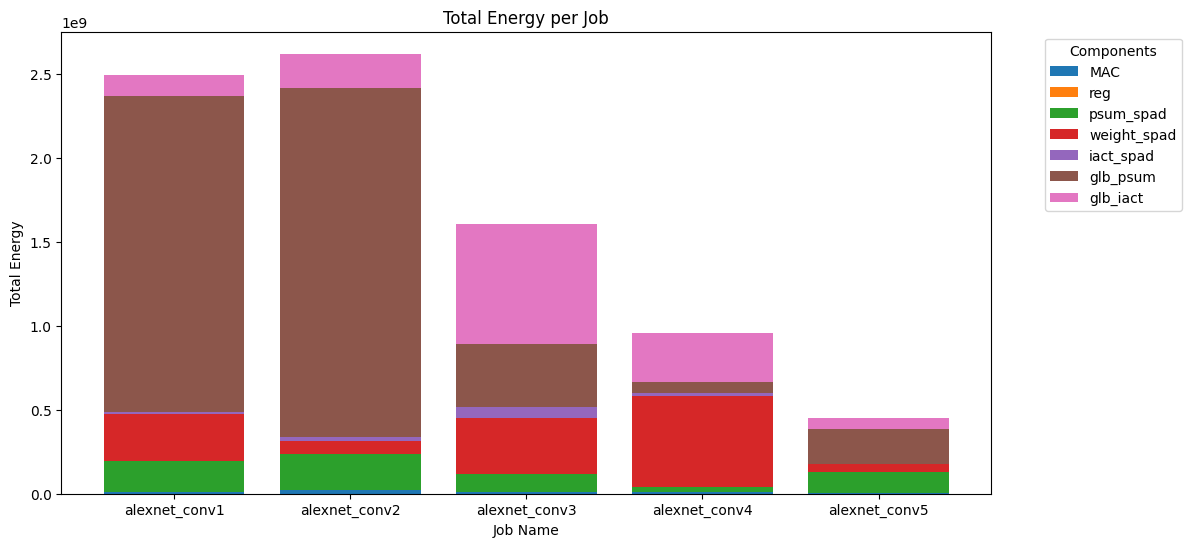

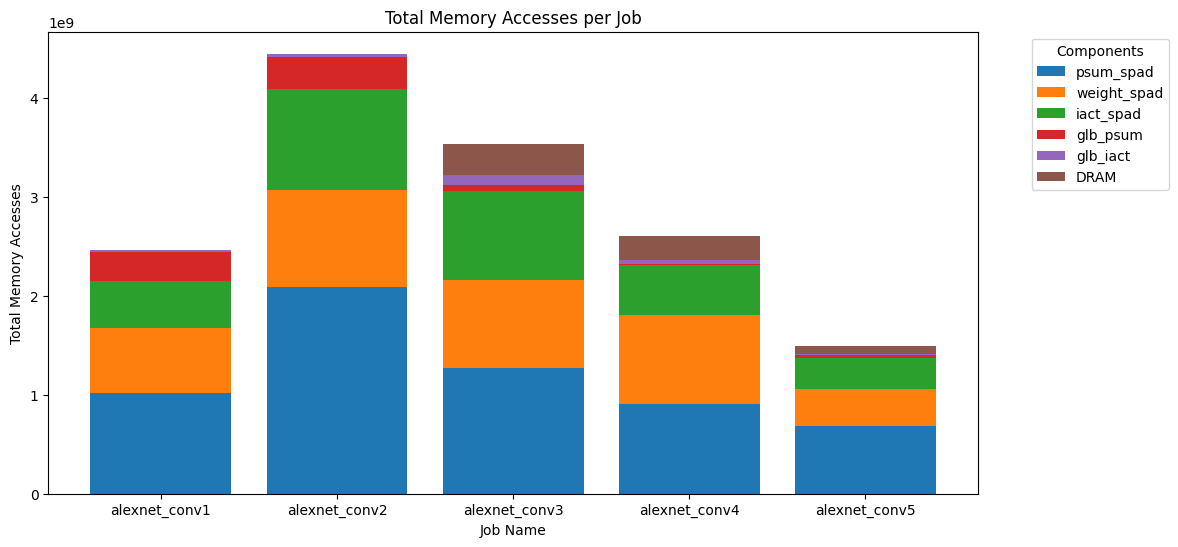

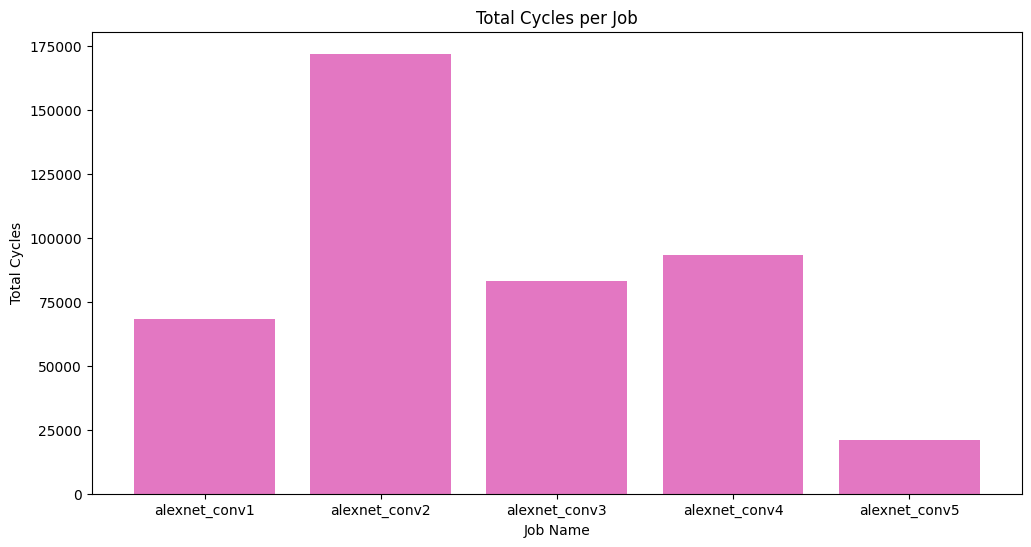

In [6]:
from IPython.display import Image
display(Image("../evaluation_setups/Eyeriss_v2/outputs_sparse_double_skip/alexnet_conv5/output/total_energy_plot.png"))
display(Image("../evaluation_setups/Eyeriss_v2/outputs_sparse_double_skip/alexnet_conv5/output/total_memory_plot.png"))
display(Image("../evaluation_setups/Eyeriss_v2/outputs_sparse_double_skip/alexnet_conv5/output/total_cycles_plot.png"))

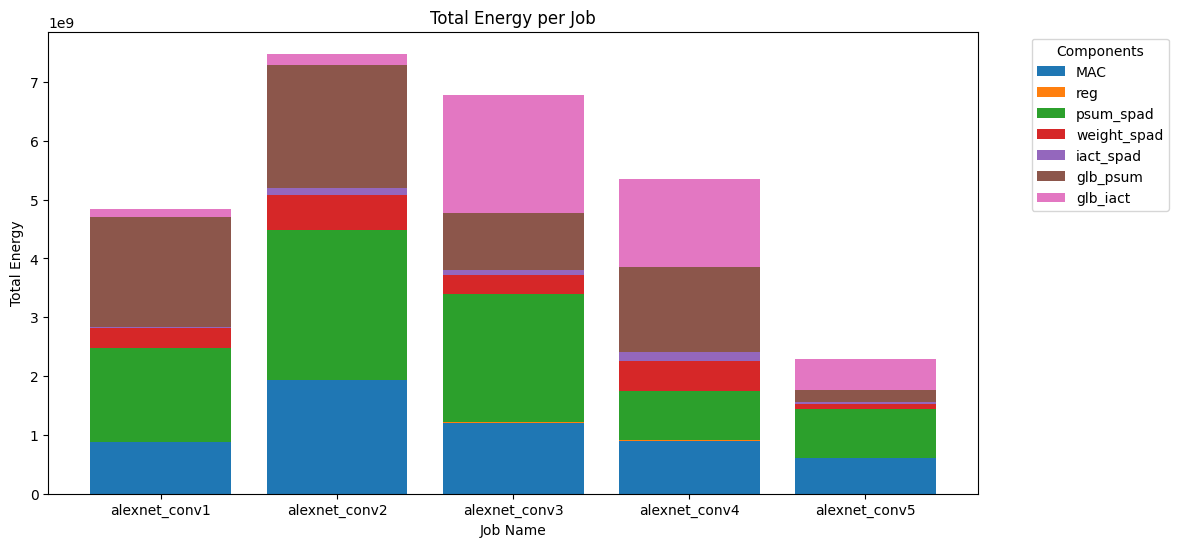

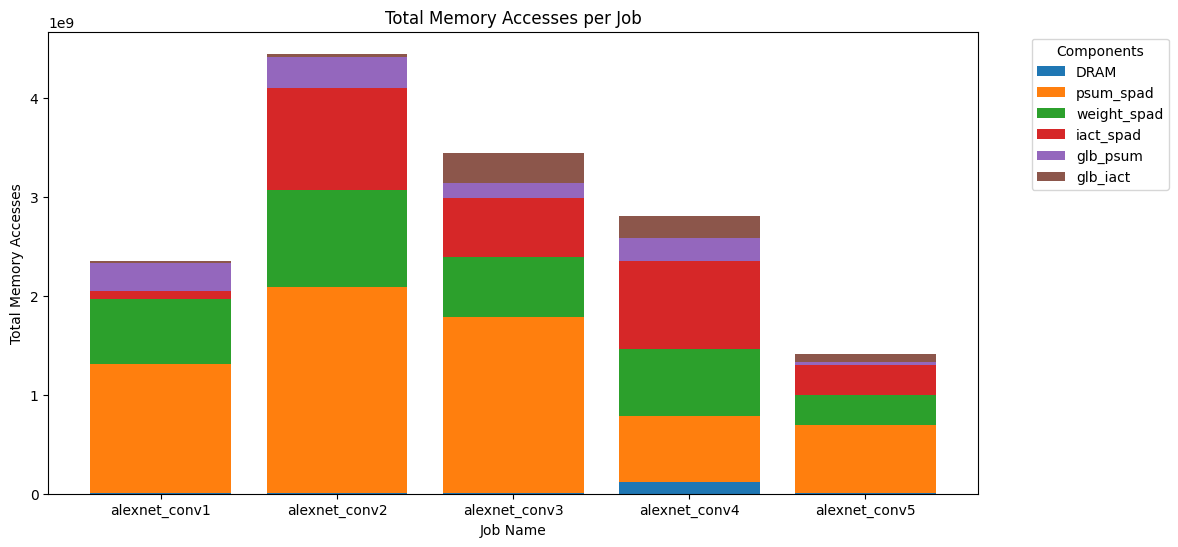

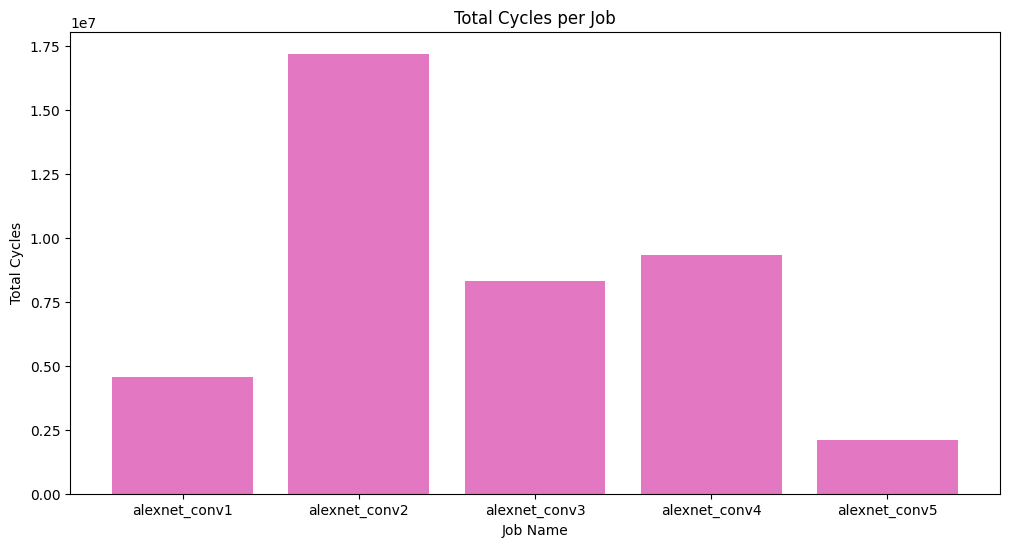

In [7]:
from IPython.display import Image
display(Image("../evaluation_setups/Eyeriss_v2/outputs_fixed_no_skip/alexnet_conv5/output/total_energy_plot.png"))
display(Image("../evaluation_setups/Eyeriss_v2/outputs_fixed_no_skip/alexnet_conv5/output/total_memory_plot.png"))
display(Image("../evaluation_setups/Eyeriss_v2/outputs_fixed_no_skip/alexnet_conv5/output/total_cycles_plot.png"))

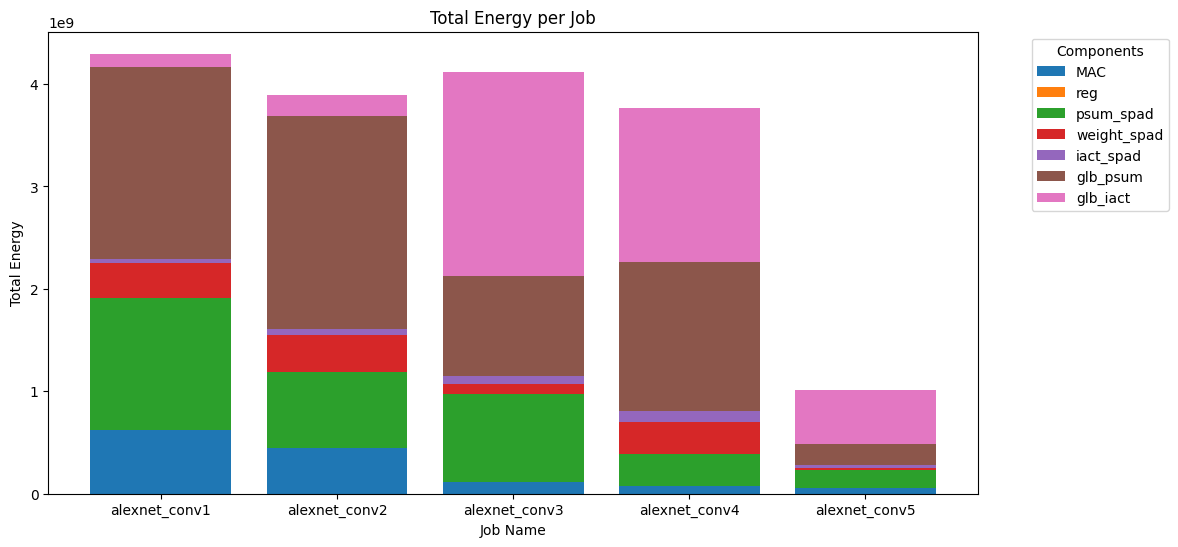

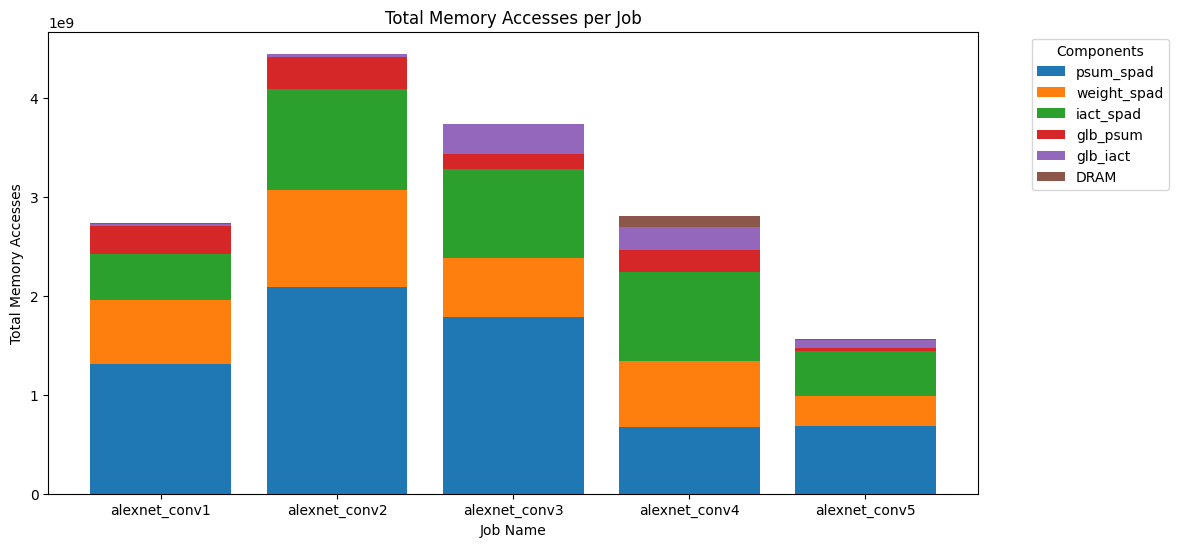

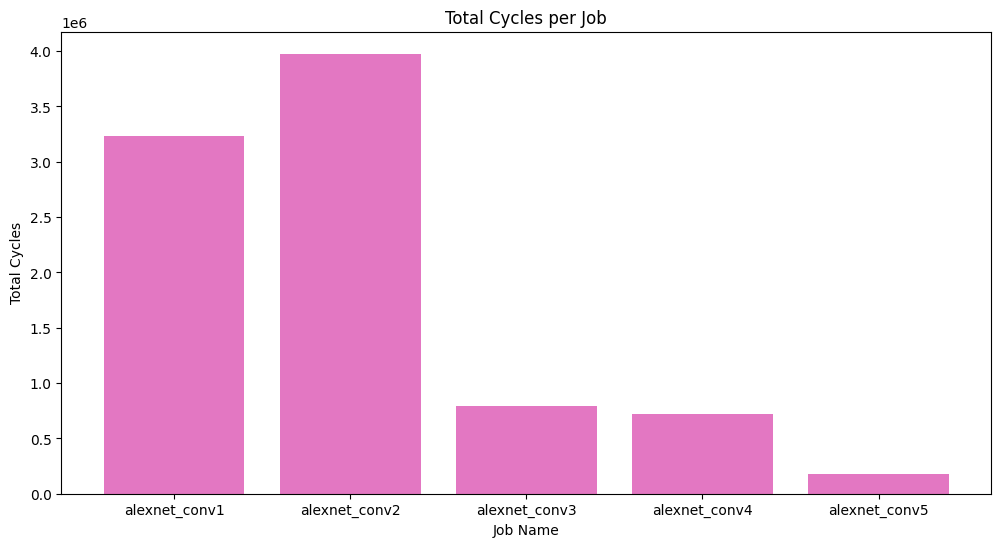

In [8]:
from IPython.display import Image
display(Image("../evaluation_setups/Eyeriss_v2/outputs_fixed_double_skip/alexnet_conv5/output/total_energy_plot.png"))
display(Image("../evaluation_setups/Eyeriss_v2/outputs_fixed_double_skip/alexnet_conv5/output/total_memory_plot.png"))
display(Image("../evaluation_setups/Eyeriss_v2/outputs_fixed_double_skip/alexnet_conv5/output/total_cycles_plot.png"))

## Irrelevant, old code

In [3]:
%%bash
cd ../evaluation_setups/Eyeriss_v2/scripts
python3 parse_and_plot.py --stats_prefix timeloop-mapper --output_dir "outputs_fixed_2"

Eyeriss DRAM Compression Ratioes (read + write)
Saved: /home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs_fixed_2/alexnet_conv5/output/energy_breakdown_plot.png
Saved: /home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs_fixed_2/alexnet_conv5/output/total_energy_plot.png
/home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs_fixed_2/alexnet_conv5
Saved: /home/workspace/2022.micro.artifact/evaluation_setups/Eyeriss_v2/scripts/../outputs_fixed_2/alexnet_conv5/output/total_memory_plot.png


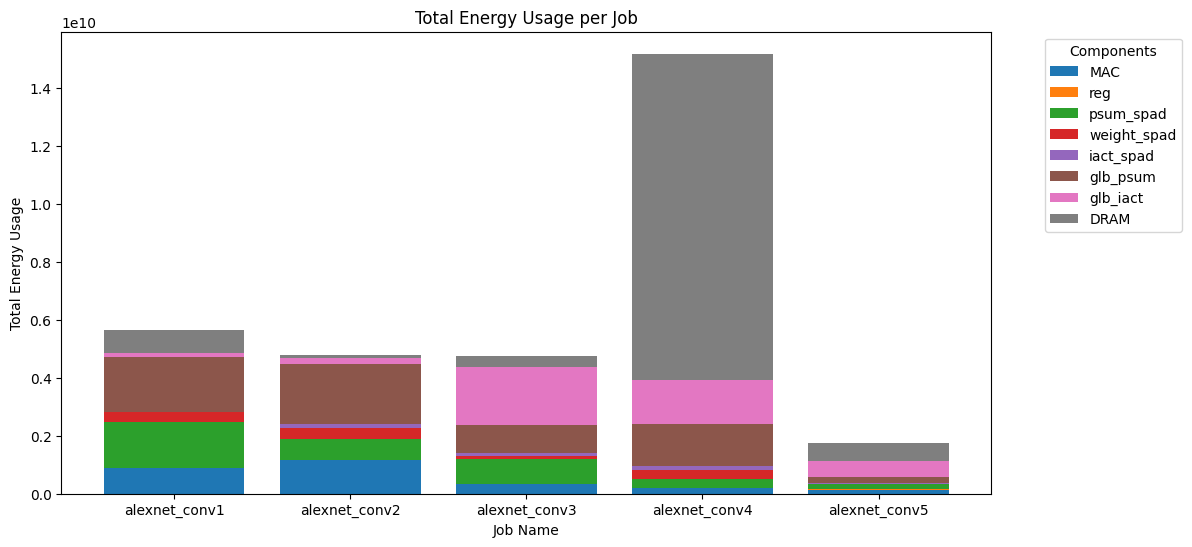

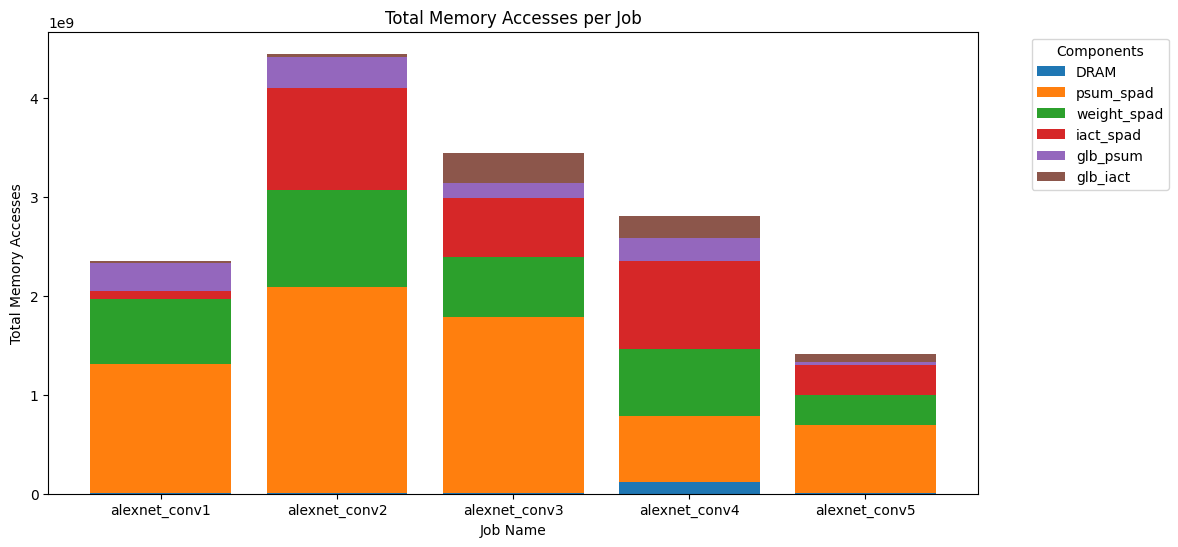

In [4]:
from IPython.display import Image
display(Image("../evaluation_setups/Eyeriss_v2/outputs_fixed_2/alexnet_conv5/output/total_energy_plot.png"))
display(Image("../evaluation_setups/Eyeriss_v2/outputs_fixed_2/alexnet_conv5/output/total_memory_plot.png"))